# Notebook 2 : Modélisation

**PLAN**
1. Objectifs

2. Chargement des données

3. Construction du protocole expérimental

4. Encodage

5. Baselines

6. Factorisation matricielle

7. SoRec

8. Extension de la factorisation matricielle avec information sociale

9. Évaluation finale


## 1. Objectifs


Ce notebook accompagne le rapport du projet RCP217. Il présente la construction du protocole expérimental, l’implémentation des modèles, la sélection des hyperparamètres et leur évaluation.

Les objectifs sont :

* construire des jeux d’apprentissage, de validation et de test adaptés aux scénarios warm-start et cold-start ;
* définir des modèles de référence ;
* mettre en œuvre une factorisation matricielle utilisant uniquement les évaluations ;
* intégrer le réseau de confiance dans la modélisation ;
* sélectionner les hyperparamètres à partir des jeux de validation ;
* comparer les modèles retenus sur les mêmes jeux de test.

## 2. Chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Chemins
DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"

RATINGS_FILE = PROCESSED_DIR / "ratings.parquet"
TRUST_FILE = PROCESSED_DIR / "trust_with_ratings.parquet"
USER_STATS_FILE = PROCESSED_DIR / "user_stats.parquet"

In [3]:
ratings = pd.read_parquet(RATINGS_FILE)
trust = pd.read_parquet(TRUST_FILE)
user_stats = pd.read_parquet(USER_STATS_FILE)

In [4]:
print(f"Ratings           : {ratings.shape}")
print(f"Relations sociales : {trust.shape}")
print(f"Statistiques users : {user_stats.shape}")

Ratings           : (1238946, 7)
Relations sociales : (509872, 2)
Statistiques users : (128962, 7)


## 3. Protocole expérimental

### 3.1 Objectif de prédiction et principe de comparaison

L’objectif est de prédire les évaluations attribuées par les utilisateurs aux items.

Deux approches seront comparées :

* une factorisation matricielle utilisant uniquement les évaluations ;
* une approche intégrant également le réseau de confiance entre utilisateurs.

L’évaluation distingue deux scénarios :

* warm-start : l’utilisateur possède des évaluations dans le jeu d’apprentissage ;
* cold-start utilisateur : l’utilisateur ne possède aucune évaluation dans le jeu d’apprentissage mais dispose d’information sociale.

Les hyperparamètres sont sélectionnés sur les jeux de validation. Les jeux de test sont réservés à l’évaluation finale.

### 3.2 Contraintes liées au découpage

Un découpage aléatoire simple peut conduire à placer dans les jeux de validation ou de test des utilisateurs ou des items absents du jeu d’apprentissage.

Pour l’évaluation en warm-start, les utilisateurs et les items présents en validation ou en test doivent également être représentés dans le jeu d’apprentissage.

Pour l’évaluation en cold-start utilisateur, toutes les évaluations de certains utilisateurs disposant d’information sociale sont volontairement retirées du jeu d’apprentissage. Les items correspondants doivent en revanche rester représentés dans l’apprentissage afin d’isoler le cold-start utilisateur du cold-start item.

Les mêmes observations sont utilisées pour comparer les différents modèles au sein de chaque scénario.

### 3.3 Définition des populations d'évaluation

Les utilisateurs évalués en warm-start conservent au moins une évaluation dans le jeu d’apprentissage. Les items évalués sont également présents dans l’apprentissage.

Cold-start utilisateur

Les utilisateurs évalués en cold-start ne disposent d’aucune évaluation dans le jeu d’apprentissage mais possèdent au moins une relation de confiance exploitable.

Les utilisateurs ne possédant qu’une seule évaluation sont retenus comme candidats : leur unique évaluation peut être réservée à la validation ou au test, tandis que leur représentation utilisateur est apprise uniquement à partir du réseau de confiance.

L’item associé doit posséder au moins une autre évaluation afin de rester représenté dans le jeu d’apprentissage.

### 3.4 Construction du découpage


#### 3.4.1 Identification des utilisateurs éligibles au cold-start

In [5]:
# Nombre d'évaluations par utilisateur
n_ratings_user = (
    ratings
    .groupby("user_id")
    .size()
)

single_rating_users = n_ratings_user[
    n_ratings_user == 1
].index

print(
    f"Utilisateurs avec exactement 1 évaluation : "
    f"{len(single_rating_users):,}"
)

Utilisateurs avec exactement 1 évaluation : 50,955


#### 3.4.2 Présence d’information sociale

In [6]:
users_with_outgoing_trust = set(
    trust["source_user"].unique()
)

cold_candidates = set(single_rating_users) & users_with_outgoing_trust

print(
    f"Avec une relation sortante exploitable : "
    f"{len(cold_candidates):,}"
)

Avec une relation sortante exploitable : 9,230


#### 3.4.3 Vérification de la contrainte sur les items

In [7]:
n_ratings_item = (
    ratings
    .groupby("item_path")
    .size()
)

In [8]:
cold_candidates_ratings = ratings[
    ratings["user_id"].isin(cold_candidates)
].copy()

In [9]:
cold_candidates_ratings["n_ratings_item"] = (
    cold_candidates_ratings["item_path"]
    .map(n_ratings_item)
)

cold_eligible = cold_candidates_ratings[
    cold_candidates_ratings["n_ratings_item"] >= 2
].copy()

In [10]:
print(
    f"Candidats cold-start              : "
    f"{len(cold_candidates_ratings):,}"
)

print(
    f"Éligibles après contrôle des items : "
    f"{len(cold_eligible):,}"
)

Candidats cold-start              : 9,230
Éligibles après contrôle des items : 8,562


#### 3.4.4 Sélection des utilisateurs cold-start

Parmi les 8 562 utilisateurs éligibles au scénario cold-start, 2 000 sont sélectionnés pour la validation et 2 000 pour le test. Les utilisateurs des deux ensembles sont distincts. Leur unique évaluation est retirée des données d'apprentissage, de sorte que leur représentation ne puisse être apprise qu'à partir de l'information sociale.

Parmi les 8 562 utilisateurs éligibles, 2 000 sont sélectionnés pour la validation cold-start et 2 000 pour le test cold-start. Les deux groupes sont distincts.

La sélection est stratifiée selon la note afin de conserver une distribution des évaluations comparable à celle de la population éligible.

In [11]:
from sklearn.model_selection import train_test_split

# Sélection de 4 000 utilisateurs parmi les utilisateurs éligibles
cold_selected, cold_remaining = train_test_split(
    cold_eligible,
    train_size=4000,
    stratify=cold_eligible["rating"],
    random_state=RANDOM_STATE
)

# Répartition équitable entre validation et test
cold_val, cold_test = train_test_split(
    cold_selected,
    test_size=0.5,
    stratify=cold_selected["rating"],
    random_state=RANDOM_STATE
)

print(f"Cold-validation : {len(cold_val):,}")
print(f"Cold-test       : {len(cold_test):,}")

Cold-validation : 2,000
Cold-test       : 2,000


In [12]:
cold_rating_distribution = pd.DataFrame({
    "éligibles": (
        cold_eligible["rating"]
        .value_counts(normalize=True)
        .sort_index() * 100
    ),
    "validation": (
        cold_val["rating"]
        .value_counts(normalize=True)
        .sort_index() * 100
    ),
    "test": (
        cold_test["rating"]
        .value_counts(normalize=True)
        .sort_index() * 100
    )
})

cold_rating_distribution.round(2)

,éligibles,validation,test
rating,,,
1.0,14.95,14.95,14.95
2.0,6.87,6.85,6.90
3.0,6.82,6.85,6.80
4.0,21.71,21.70,21.70
5.0,49.65,49.65,49.65


#### 3.4.5 Retrait des utilisateurs cold-start de l'apprentissage

In [13]:
cold_val_users = set(cold_val["user_id"])
cold_test_users = set(cold_test["user_id"])

cold_selected_users = (
    cold_val_users | cold_test_users
)

ratings_remaining = ratings[
    ~ratings["user_id"].isin(cold_selected_users)
].copy()

print(
    f"Ratings restants pour le warm-start et l'apprentissage : "
    f"{len(ratings_remaining):,}"
)

Ratings restants pour le warm-start et l'apprentissage : 1,234,946


Comme chacun des 4 000 utilisateurs possède exactement une évaluation, nous devrions avoir :
1 238 946 − 4 000 = 1 234 946 évaluations.

#### 3.4.6 Contrôle des items

In [14]:
remaining_items = set(
    ratings_remaining["item_path"]
)

val_known_items = cold_val["item_path"].isin(
    remaining_items
)

test_known_items = cold_test["item_path"].isin(
    remaining_items
)

print(
    f"Items cold-validation présents dans les données restantes : "
    f"{val_known_items.mean() * 100:.2f} %"
)

print(
    f"Items cold-test présents dans les données restantes       : "
    f"{test_known_items.mean() * 100:.2f} %"
)

print(
    f"Items cold-validation absents : "
    f"{(~val_known_items).sum():,}"
)

print(
    f"Items cold-test absents       : "
    f"{(~test_known_items).sum():,}"
)

Items cold-validation présents dans les données restantes : 100.00 %
Items cold-test présents dans les données restantes       : 100.00 %
Items cold-validation absents : 0
Items cold-test absents       : 0


Les 4 000 utilisateurs sélectionnés ne disposent d’aucune évaluation dans les données restantes. Les items présents dans les jeux cold-validation et cold-test restent en revanche représentés par les évaluations d’autres utilisateurs.

#### 3.4.7 Construction du découpage warm-start

Les évaluations restantes sont réparties entre apprentissage, validation et test selon une proportion cible d’environ 80/10/10.

Les observations de validation ou de test correspondant à un utilisateur ou à un item absent de l’apprentissage sont réintégrées dans celui-ci afin de respecter la définition du warm-start.

In [15]:
# Tirage initial 80/10/10

# 80 % train provisoire, 20 % validation + test
train_warm, temp_warm = train_test_split(
    ratings_remaining,
    test_size=0.20,
    stratify=ratings_remaining["rating"],
    random_state=RANDOM_STATE
)

# Séparation des 20 % restants en 10 % validation / 10 % test
warm_val, warm_test = train_test_split(
    temp_warm,
    test_size=0.50,
    stratify=temp_warm["rating"],
    random_state=RANDOM_STATE
)

print(f"Train provisoire : {len(train_warm):,}")
print(f"Warm-validation  : {len(warm_val):,}")
print(f"Warm-test        : {len(warm_test):,}")

Train provisoire : 987,956
Warm-validation  : 123,495
Warm-test        : 123,495


In [16]:
#  Identifier les utilisateurs absents du train

train_users = set(train_warm["user_id"])

missing_val_users = ~warm_val["user_id"].isin(train_users)
missing_test_users = ~warm_test["user_id"].isin(train_users)

print(
    f"Ratings validation avec utilisateur absent du train : "
    f"{missing_val_users.sum():,}"
)

print(
    f"Ratings test avec utilisateur absent du train       : "
    f"{missing_test_users.sum():,}"
)

Ratings validation avec utilisateur absent du train : 5,540
Ratings test avec utilisateur absent du train       : 5,581


In [17]:
# Identifier les items absents du train

train_items = set(train_warm["item_path"])

missing_val_items = ~warm_val["item_path"].isin(train_items)
missing_test_items = ~warm_test["item_path"].isin(train_items)

print(
    f"Ratings validation avec item absent du train : "
    f"{missing_val_items.sum():,}"
)

print(
    f"Ratings test avec item absent du train       : "
    f"{missing_test_items.sum():,}"
)

Ratings validation avec item absent du train : 24,274
Ratings test avec item absent du train       : 24,102


In [18]:
# Réintégration de ces observations problématiques dans le train

invalid_val = missing_val_users | missing_val_items
invalid_test = missing_test_users | missing_test_items

to_train = pd.concat([
    warm_val[invalid_val],
    warm_test[invalid_test]
])

train_warm = pd.concat([
    train_warm,
    to_train
])

warm_val = warm_val[~invalid_val].copy()
warm_test = warm_test[~invalid_test].copy()


In [19]:
# on sécurise la validation
train_users = set(train_warm["user_id"])
train_items = set(train_warm["item_path"])

invalid_val = (
    ~warm_val["user_id"].isin(train_users)
    | ~warm_val["item_path"].isin(train_items)
)

train_warm = pd.concat([
    train_warm,
    warm_val[invalid_val]
])

warm_val = warm_val[~invalid_val].copy()

In [20]:
# Recalcul utilisateurs/items connus avant de traiter le test

train_users = set(train_warm["user_id"])
train_items = set(train_warm["item_path"])

invalid_test = (
    ~warm_test["user_id"].isin(train_users)
    | ~warm_test["item_path"].isin(train_items)
)

train_warm = pd.concat([
    train_warm,
    warm_test[invalid_test]
])

warm_test = warm_test[~invalid_test].copy()

In [21]:
# Contrôle final
train_users = set(train_warm["user_id"])
train_items = set(train_warm["item_path"])

print(
    "Utilisateurs warm-validation connus :",
    f"{warm_val['user_id'].isin(train_users).mean() * 100:.2f} %"
)

print(
    "Utilisateurs warm-test connus       :",
    f"{warm_test['user_id'].isin(train_users).mean() * 100:.2f} %"
)

print(
    "Items warm-validation connus        :",
    f"{warm_val['item_path'].isin(train_items).mean() * 100:.2f} %"
)

print(
    "Items warm-test connus              :",
    f"{warm_test['item_path'].isin(train_items).mean() * 100:.2f} %"
)

Utilisateurs warm-validation connus : 100.00 %
Utilisateurs warm-test connus       : 100.00 %
Items warm-validation connus        : 100.00 %
Items warm-test connus              : 100.00 %


In [22]:
# tailles finales

n_total = (
    len(train_warm)
    + len(warm_val)
    + len(warm_test)
)

print(f"Train           : {len(train_warm):,} ({100 * len(train_warm) / n_total:.2f} %)")
print(f"Warm-validation : {len(warm_val):,} ({100 * len(warm_val) / n_total:.2f} %)")
print(f"Warm-test       : {len(warm_test):,} ({100 * len(warm_test) / n_total:.2f} %)")

Train           : 1,046,190 (84.72 %)
Warm-validation : 94,313 (7.64 %)
Warm-test       : 94,443 (7.65 %)


In [23]:
# contrôle de la stratification

rating_distribution = pd.DataFrame({
    "train": (
        train_warm["rating"]
        .value_counts(normalize=True)
        .sort_index() * 100
    ),
    "validation": (
        warm_val["rating"]
        .value_counts(normalize=True)
        .sort_index() * 100
    ),
    "test": (
        warm_test["rating"]
        .value_counts(normalize=True)
        .sort_index() * 100
    )
})

rating_distribution.round(2)

,train,validation,test
rating,,,
1.0,7.64,7.18,7.10
2.0,7.34,7.67,7.69
3.0,11.94,11.81,11.72
4.0,29.87,29.46,29.44
5.0,43.21,43.88,44.06


### 3.5 Contrôles finaux du protocole

#### 3.5.1 Absence de chevauchement entre les ensembles d’évaluation

In [24]:
print(
    "Chevauchement warm-val / warm-test :",
    len(set(warm_val.index) & set(warm_test.index))
)

print(
    "Chevauchement cold-val / cold-test :",
    len(set(cold_val.index) & set(cold_test.index))
)

Chevauchement warm-val / warm-test : 0
Chevauchement cold-val / cold-test : 0


In [25]:
eval_indices = (
    set(warm_val.index)
    | set(warm_test.index)
    | set(cold_val.index)
    | set(cold_test.index)
)

print(
    "Observations d'évaluation présentes dans le train :",
    len(set(train_warm.index) & eval_indices)
)

Observations d'évaluation présentes dans le train : 0


#### 3.5.2 Vérification du véritable cold-start

In [26]:
train_users = set(train_warm["user_id"])

print(
    "Utilisateurs cold-validation présents dans les ratings train :",
    cold_val["user_id"].isin(train_users).sum()
)

print(
    "Utilisateurs cold-test présents dans les ratings train       :",
    cold_test["user_id"].isin(train_users).sum()
)

Utilisateurs cold-validation présents dans les ratings train : 0
Utilisateurs cold-test présents dans les ratings train       : 0


#### 3.5.3 Disponibilité de l'information sociale

In [26]:
social_sources = set(trust["source_user"])

print(
    "Utilisateurs cold-validation avec relation sortante :",
    cold_val["user_id"].isin(social_sources).sum(),
    "/",
    len(cold_val)
)

print(
    "Utilisateurs cold-test avec relation sortante       :",
    cold_test["user_id"].isin(social_sources).sum(),
    "/",
    len(cold_test)
)

Utilisateurs cold-validation avec relation sortante : 2000 / 2000
Utilisateurs cold-test avec relation sortante       : 2000 / 2000


Les utilisateurs cold-start ne disposent d’aucune évaluation dans le jeu d’apprentissage mais possèdent au moins une relation de confiance exploitable.

#### 3.5.4 Vérification des items cold-start

In [27]:
train_items = set(train_warm["item_path"])

print(
    "Items cold-validation connus dans le train :",
    f"{cold_val['item_path'].isin(train_items).mean() * 100:.2f} %"
)

print(
    "Items cold-test connus dans le train       :",
    f"{cold_test['item_path'].isin(train_items).mean() * 100:.2f} %"
)

Items cold-validation connus dans le train : 100.00 %
Items cold-test connus dans le train       : 100.00 %


#### 3.5.5 Tableau récapitulatif

In [28]:
split_summary = pd.DataFrame({
    "ensemble": [
        "train",
        "warm-validation",
        "warm-test",
        "cold-validation",
        "cold-test"
    ],
    "n_ratings": [
        len(train_warm),
        len(warm_val),
        len(warm_test),
        len(cold_val),
        len(cold_test)
    ],
    "n_users": [
        train_warm["user_id"].nunique(),
        warm_val["user_id"].nunique(),
        warm_test["user_id"].nunique(),
        cold_val["user_id"].nunique(),
        cold_test["user_id"].nunique()
    ],
    "n_items": [
        train_warm["item_path"].nunique(),
        warm_val["item_path"].nunique(),
        warm_test["item_path"].nunique(),
        cold_val["item_path"].nunique(),
        cold_test["item_path"].nunique()
    ]
})

split_summary

,ensemble,n_ratings,n_users,n_items
0,train,1046190,124962,346658
1,warm-validation,94313,34468,44732
2,warm-test,94443,34480,44977
3,cold-validation,2000,2000,1787
4,cold-test,2000,2000,1754


## 4. Préparation des identifiants pour les modèles


Les identifiants des utilisateurs et des items sont convertis en indices entiers pour être utilisés par les modèles de factorisation.

L’indexation des utilisateurs doit également inclure les utilisateurs cold-start, absents des évaluations d’apprentissage mais présents dans le réseau de confiance.

### 4.1 Indexation des items

In [29]:
train_items = train_warm["item_path"].unique()

item_to_idx = {
    item: idx
    for idx, item in enumerate(train_items)
}

n_items = len(item_to_idx)

print(f"Nombre d'items indexés : {n_items:,}")

Nombre d'items indexés : 346,658


In [30]:
assert warm_val["item_path"].isin(item_to_idx).all()
assert warm_test["item_path"].isin(item_to_idx).all()
assert cold_val["item_path"].isin(item_to_idx).all()
assert cold_test["item_path"].isin(item_to_idx).all()

print("Tous les items d'évaluation sont indexés.")

Tous les items d'évaluation sont indexés.


### 4.2 Indexation des utilisateurs

In [31]:
rating_users = set(
    train_warm["user_id"]
)

social_users = (
    set(trust["source_user"])
    | set(trust["target_user"])
)

model_users = sorted(
    rating_users | social_users
)

user_to_idx = {
    user: idx
    for idx, user in enumerate(model_users)
}

n_users = len(user_to_idx)

print(f"Utilisateurs avec ratings train : {len(rating_users):,}")
print(f"Utilisateurs du réseau          : {len(social_users):,}")
print(f"Utilisateurs indexés            : {n_users:,}")

Utilisateurs avec ratings train : 124,962
Utilisateurs du réseau          : 63,559
Utilisateurs indexés            : 128,962


### 4.3 Vérification des utilisateurs d’évaluation

In [32]:
print(
    "Warm-validation indexée :",
    f"{warm_val['user_id'].isin(user_to_idx).mean() * 100:.2f} %"
)

print(
    "Warm-test indexé        :",
    f"{warm_test['user_id'].isin(user_to_idx).mean() * 100:.2f} %"
)

print(
    "Cold-validation indexée :",
    f"{cold_val['user_id'].isin(user_to_idx).mean() * 100:.2f} %"
)

print(
    "Cold-test indexé        :",
    f"{cold_test['user_id'].isin(user_to_idx).mean() * 100:.2f} %"
)

Warm-validation indexée : 100.00 %
Warm-test indexé        : 100.00 %
Cold-validation indexée : 100.00 %
Cold-test indexé        : 100.00 %


In [33]:
cold_users = (
    set(cold_val["user_id"])
    | set(cold_test["user_id"])
)

print(
    "Utilisateurs cold-start sans rating train :",
    len(cold_users - rating_users)
)

print(
    "Utilisateurs cold-start présents dans le réseau :",
    len(cold_users & social_users)
)

Utilisateurs cold-start sans rating train : 4000
Utilisateurs cold-start présents dans le réseau : 4000


### 4.4 Encodage des évaluations

In [34]:
def encode_ratings(df, user_to_idx, item_to_idx):
    encoded = df[["user_id", "item_path", "rating"]].copy()

    encoded["user_idx"] = (
        encoded["user_id"]
        .map(user_to_idx)
        .astype("int32")
    )

    encoded["item_idx"] = (
        encoded["item_path"]
        .map(item_to_idx)
        .astype("int32")
    )

    return encoded[
        ["user_idx", "item_idx", "rating"]
    ]

In [35]:
train_encoded = encode_ratings(
    train_warm,
    user_to_idx,
    item_to_idx
)

warm_val_encoded = encode_ratings(
    warm_val,
    user_to_idx,
    item_to_idx
)

warm_test_encoded = encode_ratings(
    warm_test,
    user_to_idx,
    item_to_idx
)

cold_val_encoded = encode_ratings(
    cold_val,
    user_to_idx,
    item_to_idx
)

cold_test_encoded = encode_ratings(
    cold_test,
    user_to_idx,
    item_to_idx
)

In [36]:
print("Train           :", train_encoded.shape)
print("Warm-validation :", warm_val_encoded.shape)
print("Warm-test       :", warm_test_encoded.shape)
print("Cold-validation :", cold_val_encoded.shape)
print("Cold-test       :", cold_test_encoded.shape)

Train           : (1046190, 3)
Warm-validation : (94313, 3)
Warm-test       : (94443, 3)
Cold-validation : (2000, 3)
Cold-test       : (2000, 3)


### 4.5 Encodage du réseau social

In [37]:
trust_encoded = trust.copy()

trust_encoded["source_idx"] = (
    trust_encoded["source_user"]
    .map(user_to_idx)
    .astype("int32")
)

trust_encoded["target_idx"] = (
    trust_encoded["target_user"]
    .map(user_to_idx)
    .astype("int32")
)

trust_encoded = trust_encoded[
    ["source_idx", "target_idx"]
]

In [38]:
print(f"Relations sociales encodées : {len(trust_encoded):,}")

print(
    "Valeurs manquantes :",
    trust_encoded.isna().sum().sum()
)

Relations sociales encodées : 509,872
Valeurs manquantes : 0


Les 4 000 utilisateurs cold-start, absents des évaluations d’apprentissage, restent indexés grâce au réseau de confiance.

Tous les utilisateurs et items des jeux d’évaluation disposent ainsi d’un identifiant utilisable par les modèles. Les 509 872 relations de confiance exploitables sont conservées après encodage.

## 5. Baselines

### 5.1 Choix des baselines

Deux modèles simples sont utilisés comme références avant d’évaluer les modèles de factorisation.

La première baseline prédit systématiquement la moyenne globale des évaluations du jeu d’apprentissage.

La seconde prend en compte les biais utilisateur et item. Pour un utilisateur et un item connus, la prédiction s’écrit :
$$
\hat{r}_{ui} = \mu + b_u + b_i
$$

où $\mu$ est la moyenne globale des évaluations d'apprentissage, 

$b_u$ le biais associé à l'utilisateur 

et $b_i$ celui associé à l'item.

Dans le scénario cold-start, le biais utilisateur ne peut pas être estimé puisque l’utilisateur ne possède aucune évaluation dans le jeu d’apprentissage. La prédiction repose alors sur :

$$ \hat{r}_{ui} = \mu + b_i $$

Ces deux modèles servent de références pour évaluer l’apport des modèles de factorisation.

### 5.2 Implémentation des baselines et des métriques

#### 5.2.1 Métrique d'évaluation

In [39]:
def mae(y_true, y_pred):
    return np.mean(
        np.abs(y_true - y_pred)
    )

La qualité des prédictions est mesurée à l'aide de la Mean Absolute Error (MAE), également utilisée dans l'article SoRec.

La MAE mesure l'écart absolu moyen entre les notes observées et prédites.
Sur l'échelle de notation utilisée ici, une MAE de 0,8 correspond par exemple à une erreur absolue moyenne de 0,8 point.

Une valeur plus faible indique de meilleures prédictions.

#### 5.2.2 Baseline par moyenne globale

In [40]:
global_mean = train_encoded["rating"].mean()

y_warm_val = warm_val_encoded[
    "rating"
].to_numpy(dtype=np.float32)

y_cold_val = cold_val_encoded[
    "rating"
].to_numpy(dtype=np.float32)

print(f"Moyenne globale du train : {global_mean:.4f}")

Moyenne globale du train : 3.9368


In [41]:
def predict_global_mean(df, global_mean):
    return np.full(
        len(df),
        global_mean,
        dtype=float
    )

In [42]:
pred_mean_warm = predict_global_mean(
    warm_val_encoded,
    global_mean
)

print(
    f"MAE warm-validation : "
    f"{mae(y_warm_val, pred_mean_warm):.4f}"
)

MAE warm-validation : 0.9553


#### 5.2.3 Baseline avec biais utilisateur et item

In [43]:
train_users_idx = (
    train_encoded["user_idx"]
    .to_numpy(dtype=np.int32)
)

train_items_idx = (
    train_encoded["item_idx"]
    .to_numpy(dtype=np.int32)
)

train_ratings = (
    train_encoded["rating"]
    .to_numpy(dtype=np.float32)
)

In [44]:
# Estimation des biais
def fit_bias_model(
    user_idx,
    item_idx,
    ratings,
    n_users,
    n_items,
    global_mean,
    reg=10.0,
    n_iter=10
):
    user_bias = np.zeros(n_users)
    item_bias = np.zeros(n_items)

    user_counts = np.bincount(
        user_idx,
        minlength=n_users
    )

    item_counts = np.bincount(
        item_idx,
        minlength=n_items
    )

    for _ in range(n_iter):

        # Mise à jour des biais utilisateurs
        residuals = (
            ratings
            - global_mean
            - item_bias[item_idx]
        )

        user_sums = np.bincount(
            user_idx,
            weights=residuals,
            minlength=n_users
        )

        user_bias = (
            user_sums
            / (user_counts + reg)
        )

        # Mise à jour des biais items
        residuals = (
            ratings
            - global_mean
            - user_bias[user_idx]
        )

        item_sums = np.bincount(
            item_idx,
            weights=residuals,
            minlength=n_items
        )

        item_bias = (
            item_sums
            / (item_counts + reg)
        )

    return user_bias, item_bias

#### 5.2.4 Fonction de prédiction

In [45]:
def predict_bias_model(
    df,
    global_mean,
    user_bias,
    item_bias
):
    users = df["user_idx"].to_numpy()
    items = df["item_idx"].to_numpy()

    predictions = (
        global_mean
        + user_bias[users]
        + item_bias[items]
    )

    return np.clip(predictions, 1, 5)

### 5.3 Sélection de la régularisation sur warm-start

Le paramètre de régularisation du modèle avec biais est sélectionné à partir du jeu de validation warm-start. Plusieurs valeurs sont testées et celle minimisant la MAE est retenue.

Le jeu de test n’intervient pas dans cette sélection.

#### 5.3.1 Baseline moyenne globale

In [46]:
pred_mean_warm = predict_global_mean(
    warm_val_encoded,
    global_mean
)

print(
    f"Moyenne globale — MAE : "
    f"{mae(y_warm_val, pred_mean_warm):.4f}"
)

Moyenne globale — MAE : 0.9553


#### 5.3.2 Recherche de la régularisation

In [48]:
bias_results = []

for reg in [1, 5, 10, 20, 50]:

    user_bias_tmp, item_bias_tmp = fit_bias_model(
        train_users_idx,
        train_items_idx,
        train_ratings,
        n_users,
        n_items,
        global_mean,
        reg=reg,
        n_iter=10
    )

    pred = predict_bias_model(
        warm_val_encoded,
        global_mean,
        user_bias_tmp,
        item_bias_tmp
    )

    bias_results.append({
        "reg": reg,
        "MAE": mae(
            y_warm_val,
            pred
        )
    })

bias_results = (
    pd.DataFrame(bias_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

bias_results

,reg,MAE
0,1,0.808637
1,5,0.818911
2,10,0.832415
3,20,0.849330
4,50,0.873697


#### 5.3.3 Sélection

In [49]:
best_reg_bias = bias_results.loc[
    0,
    "reg"
]

print(
    f"Meilleure régularisation : "
    f"{best_reg_bias:g}"
)

Meilleure régularisation : 1


In [50]:
user_bias, item_bias = fit_bias_model(
    train_users_idx,
    train_items_idx,
    train_ratings,
    n_users,
    n_items,
    global_mean,
    reg=best_reg_bias,
    n_iter=10
)

#### 5.3.4 Comparaison sur warm-validation

In [51]:
pred_bias_warm = predict_bias_model(
    warm_val_encoded,
    global_mean,
    user_bias,
    item_bias
)

baseline_warm_results = pd.DataFrame({
    "modèle": [
        "Moyenne globale",
        "Biais utilisateur + item"
    ],
    "MAE": [
        mae(y_warm_val, pred_mean_warm),
        mae(y_warm_val, pred_bias_warm)
    ]
})

baseline_warm_results.round(4)

,modèle,MAE
0,Moyenne globale,0.9553
1,Biais utilisateur + item,0.8086


#### 5.3.5 Évaluation sur la validation cold-start

In [52]:
pred_mean_cold = predict_global_mean(
    cold_val_encoded,
    global_mean
)

pred_bias_cold = predict_bias_model(
    cold_val_encoded,
    global_mean,
    user_bias,
    item_bias
)

baseline_cold_results = pd.DataFrame({
    "modèle": [
        "Moyenne globale",
        "Biais item"
    ],
    "MAE": [
        mae(y_cold_val, pred_mean_cold),
        mae(y_cold_val, pred_bias_cold)
    ]
})

baseline_cold_results.round(4)

,modèle,MAE
0,Moyenne globale,1.1775
1,Biais item,1.0323


La régularisation $\lambda=1$ minimise la MAE sur la validation warm-start et est retenue pour la configuration warm-start.

### 5.4 Sélection spécifique au cold-start

Le paramètre de régularisation est également sélectionné à partir de la validation cold-start afin d’obtenir une configuration adaptée à ce scénario.

Le jeu de test n’intervient pas dans cette sélection.

In [47]:
bias_cold_results = []

for reg in [1, 5, 10, 20, 50]:

    user_bias_tmp, item_bias_tmp = fit_bias_model(
        train_users_idx,
        train_items_idx,
        train_ratings,
        n_users,
        n_items,
        global_mean,
        reg=reg,
        n_iter=10
    )

    pred = predict_bias_model(
        cold_val_encoded,
        global_mean,
        user_bias_tmp,
        item_bias_tmp
    )

    bias_cold_results.append({
        "reg": reg,
        "MAE": mae(
            y_cold_val,
            pred
        )
    })

bias_cold_results = (
    pd.DataFrame(bias_cold_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

bias_cold_results

,reg,MAE
0,1,1.032331
1,5,1.050716
2,10,1.064166
3,20,1.080239
4,50,1.103964


In [49]:
best_reg_bias_cold = bias_cold_results.loc[
    0,
    "reg"
]

print(
    f"Meilleure régularisation cold-start : "
    f"{best_reg_bias_cold:g}"
)

Meilleure régularisation cold-start : 1


In [50]:
user_bias_cold, item_bias_cold = fit_bias_model(
    train_users_idx,
    train_items_idx,
    train_ratings,
    n_users,
    n_items,
    global_mean,
    reg=best_reg_bias_cold,
    n_iter=10
)

pred_bias_cold_selected = predict_bias_model(
    cold_val_encoded,
    global_mean,
    user_bias_cold,
    item_bias_cold
)

print(
    f"MAE cold-validation : "
    f"{mae(y_cold_val, pred_bias_cold_selected):.4f}"
)

MAE cold-validation : 1.0323


La régularisation $\lambda=1$ minimise également la MAE sur la validation cold-start. La même configuration est donc retenue pour les deux scénarios.

## 6. Factorisation matricielle non sociale

### 6.1 Formulation du modèle

La factorisation matricielle représente chaque utilisateur et chaque item par un vecteur de facteurs latents. La prédiction d'une évaluation est définie par :

$$
\hat r_{ui} =
\mu + b_u + b_i + U_u^\top V_i
$$

où :

- $\mu$ est la moyenne globale des évaluations d'apprentissage ;
- $b_u$ et $b_i$ sont les biais utilisateur et item ;
- $U_u$ est le vecteur latent de l'utilisateur $u$ ;
- $V_i$ est le vecteur latent de l'item $i$.

Les paramètres sont appris par descente de gradient stochastique en minimisant une erreur quadratique régularisée.

Dans le scénario cold-start, les utilisateurs concernés ne disposent d’aucune évaluation dans le jeu d’apprentissage. Leur biais et leurs facteurs latents utilisateur ne peuvent donc pas être appris à partir des évaluations et sont maintenus à zéro.

#### 6.2 Implémentation

In [48]:
def initialize_mf(
    n_users,
    n_items,
    n_factors,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    user_factors = rng.normal(
        0,
        0.01,
        size=(n_users, n_factors)
    ).astype(np.float32)

    item_factors = rng.normal(
        0,
        0.01,
        size=(n_items, n_factors)
    ).astype(np.float32)

    user_bias = np.zeros(
        n_users,
        dtype=np.float32
    )

    item_bias = np.zeros(
        n_items,
        dtype=np.float32
    )

    return (
        user_factors,
        item_factors,
        user_bias,
        item_bias
    )

In [49]:
def predict_mf(
    df,
    global_mean,
    user_factors,
    item_factors,
    user_bias,
    item_bias
):
    users = (
        df["user_idx"]
        .to_numpy(dtype=np.int32)
    )

    items = (
        df["item_idx"]
        .to_numpy(dtype=np.int32)
    )

    latent = np.sum(
        user_factors[users]
        * item_factors[items],
        axis=1
    )

    predictions = (
        global_mean
        + user_bias[users]
        + item_bias[items]
        + latent
    )

    return np.clip(
        predictions,
        1,
        5
    )

In [50]:
def fit_mf(
    user_idx,
    item_idx,
    ratings,
    n_users,
    n_items,
    global_mean,
    val_df,
    val_ratings,
    n_factors=10,
    learning_rate=0.01,
    reg=0.05,
    max_epochs=50,
    patience=5,
    min_delta=1e-4,
    random_state=42,
    verbose=True
):

    (
        user_factors,
        item_factors,
        user_bias,
        item_bias
    ) = initialize_mf(
        n_users,
        n_items,
        n_factors,
        random_state
    )

    rng = np.random.default_rng(random_state)

    n_obs = len(ratings)

    user_counts = np.bincount(
        user_idx,
        minlength=n_users
    )

    history = []

    best_val_mae = np.inf
    best_epoch = 0
    best_params = None
    epochs_without_improvement = 0

    for epoch in range(max_epochs):

        order = rng.permutation(n_obs)

        for idx in order:

            u = user_idx[idx]
            i = item_idx[idx]
            r = ratings[idx]

            pred = (
                global_mean
                + user_bias[u]
                + item_bias[i]
                + np.dot(
                    user_factors[u],
                    item_factors[i]
                )
            )

            error = r - pred

            user_vector = user_factors[u].copy()
            item_vector = item_factors[i].copy()

            user_bias[u] += learning_rate * (
                error
                - reg * user_bias[u]
            )

            item_bias[i] += learning_rate * (
                error
                - reg * item_bias[i]
            )

            user_factors[u] += learning_rate * (
                error * item_vector
                - reg * user_vector
            )

            item_factors[i] += learning_rate * (
                error * user_vector
                - reg * item_vector
            )

        # Les utilisateurs cold-start ne doivent pas
        # conserver de facteurs aléatoires.
        user_factors[user_counts == 0] = 0
        user_bias[user_counts == 0] = 0

        pred_val = predict_mf(
            val_df,
            global_mean,
            user_factors,
            item_factors,
            user_bias,
            item_bias
        )

        val_mae = mae(
            val_ratings,
            pred_val
        )

        history.append({
            "epoch": epoch + 1,
            "val_MAE": val_mae
        })

        if verbose:
            print(
                f"Epoch {epoch + 1:2d} "
                f"- validation MAE : "
                f"{val_mae:.4f}"
            )

        if best_val_mae - val_mae > min_delta:

            best_val_mae = val_mae
            best_epoch = epoch + 1
            epochs_without_improvement = 0

            best_params = (
                user_factors.copy(),
                item_factors.copy(),
                user_bias.copy(),
                item_bias.copy()
            )

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:

            if verbose:
                print(
                    f"Early stopping à l'époque "
                    f"{epoch + 1} "
                    f"(meilleure époque : "
                    f"{best_epoch})"
                )

            break

    if best_params is not None:
        (
            user_factors,
            item_factors,
            user_bias,
            item_bias
        ) = best_params

    return (
        user_factors,
        item_factors,
        user_bias,
        item_bias,
        pd.DataFrame(history),
        best_epoch,
        best_val_mae
    )

### 6.3 Etude de la convergence

In [58]:
(
    user_factors_tmp,
    item_factors_tmp,
    user_bias_tmp,
    item_bias_tmp,
    mf_history,
    best_epoch_tmp,
    best_mae_tmp
) = fit_mf(
    train_users_idx,
    train_items_idx,
    train_ratings,
    n_users,
    n_items,
    global_mean,
    val_df=warm_val_encoded,
    val_ratings=y_warm_val,
    n_factors=10,
    learning_rate=0.01,
    reg=0.05,
    max_epochs=50,
    patience=5,
    min_delta=1e-4,
    random_state=RANDOM_STATE
)

Epoch  1 - validation MAE : 0.8846
Epoch  2 - validation MAE : 0.8650
Epoch  3 - validation MAE : 0.8532
Epoch  4 - validation MAE : 0.8453
Epoch  5 - validation MAE : 0.8402
Epoch  6 - validation MAE : 0.8350
Epoch  7 - validation MAE : 0.8318
Epoch  8 - validation MAE : 0.8286
Epoch  9 - validation MAE : 0.8258
Epoch 10 - validation MAE : 0.8239
Epoch 11 - validation MAE : 0.8222
Epoch 12 - validation MAE : 0.8205
Epoch 13 - validation MAE : 0.8192
Epoch 14 - validation MAE : 0.8180
Epoch 15 - validation MAE : 0.8173
Epoch 16 - validation MAE : 0.8162
Epoch 17 - validation MAE : 0.8155
Epoch 18 - validation MAE : 0.8147
Epoch 19 - validation MAE : 0.8141
Epoch 20 - validation MAE : 0.8138
Epoch 21 - validation MAE : 0.8129
Epoch 22 - validation MAE : 0.8127
Epoch 23 - validation MAE : 0.8118
Epoch 24 - validation MAE : 0.8117
Epoch 25 - validation MAE : 0.8115
Epoch 26 - validation MAE : 0.8114
Epoch 27 - validation MAE : 0.8112
Epoch 28 - validation MAE : 0.8107
Epoch 29 - validatio

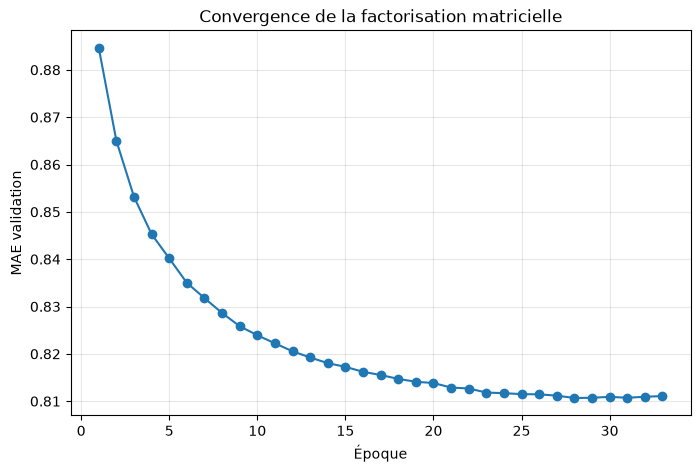

In [59]:
plt.figure(figsize=(8, 5))

plt.plot(
    mf_history["epoch"],
    mf_history["val_MAE"],
    marker="o"
)

plt.xlabel("Époque")
plt.ylabel("MAE validation")
plt.title("Convergence de la factorisation matricielle")
plt.grid(alpha=0.3)

plt.show()

In [60]:
print(
    f"Meilleure époque : "
    f"{best_epoch_tmp}"
)

print(
    f"Meilleure MAE validation : "
    f"{best_mae_tmp:.4f}"
)

Meilleure époque : 28
Meilleure MAE validation : 0.8107


### 6.4 Sélection des hyperparamètres orientée warm-start

Une recherche séquentielle des hyperparamètres est réalisée sur le jeu de validation warm-start. La dimension latente est d’abord sélectionnée, puis la régularisation et le taux d’apprentissage sont ajustés successivement en conservant les valeurs retenues aux étapes précédentes.

Cette stratégie permet de limiter le nombre d’entraînements par rapport à une recherche exhaustive de toutes les combinaisons.

#### 6.4.1 Recherche de la dimension latente

In [109]:
factor_values = [5, 10, 20]

factor_results = []

for n_factors in factor_values:

    (
        user_factors_tmp,
        item_factors_tmp,
        user_bias_tmp,
        item_bias_tmp,
        history_tmp,
        best_epoch_tmp,
        best_mae_tmp
    ) = fit_mf(
        train_users_idx,
        train_items_idx,
        train_ratings,
        n_users,
        n_items,
        global_mean,
        val_df=warm_val_encoded,
        val_ratings=y_warm_val,
        n_factors=n_factors,
        learning_rate=0.01,
        reg=0.05,
        max_epochs=50,
        patience=5,
        min_delta=1e-4,
        random_state=RANDOM_STATE,
        verbose=False
    )

    factor_results.append({
        "n_factors": n_factors,
        "best_epoch": best_epoch_tmp,
        "MAE": best_mae_tmp
    })

factor_results = (
    pd.DataFrame(factor_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

factor_results

,n_factors,best_epoch,MAE
0,5,31,0.809992
1,20,28,0.810486
2,10,28,0.810676


La dimension $k=5$ minimise la MAE sur la validation warm-start et est retenue pour la suite de la recherche.

In [110]:
best_n_factors = int(
    factor_results.loc[0, "n_factors"]
)

print(
    f"Dimension retenue : "
    f"{best_n_factors}"
)

Dimension retenue : 5


#### 6.4.2 Recherche de la régularisation

In [111]:
reg_values = [
    0.01,
    0.05,
    0.10,
    0.20
]


reg_results = []

for reg in reg_values:

    (
        user_factors_tmp,
        item_factors_tmp,
        user_bias_tmp,
        item_bias_tmp,
        history_tmp,
        best_epoch_tmp,
        best_mae_tmp
    ) = fit_mf(
        train_users_idx,
        train_items_idx,
        train_ratings,
        n_users,
        n_items,
        global_mean,
        val_df=warm_val_encoded,
        val_ratings=y_warm_val,
        n_factors=best_n_factors,
        learning_rate=0.01,
        reg=reg,
        max_epochs=50,
        patience=5,
        min_delta=1e-4,
        random_state=RANDOM_STATE,
        verbose=False
    )

    reg_results.append({
        "reg": reg,
        "best_epoch": best_epoch_tmp,
        "MAE": best_mae_tmp
    })

reg_results = (
    pd.DataFrame(reg_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

reg_results

,reg,best_epoch,MAE
0,0.05,31,0.809992
1,0.01,23,0.810852
2,0.10,36,0.812243
3,0.20,36,0.818230


In [112]:
best_reg_mf = float(
    reg_results.loc[0, "reg"]
)

print(
    f"Régularisation retenue : "
    f"{best_reg_mf}"
)

Régularisation retenue : 0.05


La régularisation $\lambda=0{,}05$ minimise la MAE sur la validation warm-start et est retenue pour la suite.

#### 6.4.3 Recherche du learning rate

In [113]:
lr_values = [
    0.005,
    0.01,
    0.02
]

lr_results = []

for learning_rate in lr_values:

    (
        user_factors_tmp,
        item_factors_tmp,
        user_bias_tmp,
        item_bias_tmp,
        history_tmp,
        best_epoch_tmp,
        best_mae_tmp
    ) = fit_mf(
        train_users_idx,
        train_items_idx,
        train_ratings,
        n_users,
        n_items,
        global_mean,
        val_df=warm_val_encoded,
        val_ratings=y_warm_val,
        n_factors=best_n_factors,
        learning_rate=learning_rate,
        reg=best_reg_mf,
        max_epochs=50,
        patience=5,
        min_delta=1e-4,
        random_state=RANDOM_STATE,
        verbose=False
    )

    lr_results.append({
        "learning_rate": learning_rate,
        "best_epoch": best_epoch_tmp,
        "MAE": best_mae_tmp
    })

lr_results = (
    pd.DataFrame(lr_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

lr_results

,learning_rate,best_epoch,MAE
0,0.010,31,0.809992
1,0.020,16,0.810231
2,0.005,49,0.811257


In [114]:
best_lr_mf = float(
    lr_results.loc[0, "learning_rate"]
)

print(
    f"Learning rate retenu : "
    f"{best_lr_mf}"
)

Learning rate retenu : 0.01


Le taux d’apprentissage $\eta=0{,}01$ minimise la MAE sur la validation warm-start et est retenu.

#### 6.4.5 Évaluation du modèle retenu sur validation warm-start

In [62]:
(
    user_factors_mf,
    item_factors_mf,
    user_bias_mf,
    item_bias_mf,
    mf_history,
    best_epoch_mf,
    best_mae_mf
) = fit_mf(
    train_users_idx,
    train_items_idx,
    train_ratings,
    n_users,
    n_items,
    global_mean,
    val_df=warm_val_encoded,
    val_ratings=y_warm_val,
    n_factors=5,
    learning_rate=0.01,
    reg=0.05,
    max_epochs=50,
    patience=5,
    min_delta=1e-4,
    random_state=RANDOM_STATE
)

Epoch  1 - validation MAE : 0.8846
Epoch  2 - validation MAE : 0.8650
Epoch  3 - validation MAE : 0.8532
Epoch  4 - validation MAE : 0.8453
Epoch  5 - validation MAE : 0.8402
Epoch  6 - validation MAE : 0.8350
Epoch  7 - validation MAE : 0.8318
Epoch  8 - validation MAE : 0.8286
Epoch  9 - validation MAE : 0.8258
Epoch 10 - validation MAE : 0.8239
Epoch 11 - validation MAE : 0.8222
Epoch 12 - validation MAE : 0.8205
Epoch 13 - validation MAE : 0.8192
Epoch 14 - validation MAE : 0.8180
Epoch 15 - validation MAE : 0.8173
Epoch 16 - validation MAE : 0.8162
Epoch 17 - validation MAE : 0.8155
Epoch 18 - validation MAE : 0.8147
Epoch 19 - validation MAE : 0.8141
Epoch 20 - validation MAE : 0.8138
Epoch 21 - validation MAE : 0.8128
Epoch 22 - validation MAE : 0.8126
Epoch 23 - validation MAE : 0.8118
Epoch 24 - validation MAE : 0.8116
Epoch 25 - validation MAE : 0.8113
Epoch 26 - validation MAE : 0.8112
Epoch 27 - validation MAE : 0.8109
Epoch 28 - validation MAE : 0.8103
Epoch 29 - validatio

In [63]:
pred_mf_warm = predict_mf(
    warm_val_encoded,
    global_mean,
    user_factors_mf,
    item_factors_mf,
    user_bias_mf,
    item_bias_mf
)

pred_mf_cold = predict_mf(
    cold_val_encoded,
    global_mean,
    user_factors_mf,
    item_factors_mf,
    user_bias_mf,
    item_bias_mf
)

mf_val_results = pd.DataFrame({
    "scénario": [
        "Warm-start",
        "Cold-start"
    ],
    "MAE": [
        mae(
            y_warm_val,
            pred_mf_warm
        ),
        mae(
            y_cold_val,
            pred_mf_cold
        )
    ]
})

mf_val_results.round(4)

,scénario,MAE
0,Warm-start,0.8100
1,Cold-start,1.0343


Configuration retenue pour le warm-start :

* $k=5$
* $\lambda=0{,}05$
* $\eta=0{,}01$

Elle obtient une MAE de 0,8100 sur la validation warm-start et de 1,0343 sur la validation cold-start.

### 6.5 Sélection des hyperparamètres sur la validation cold-start

Les hyperparamètres précédents ont été sélectionnés sur la validation warm-start. Afin de vérifier que la régularisation retenue reste adaptée au scénario cold-start, plusieurs valeurs de régularisation sont comparées sur la validation cold-start, en conservant la dimension latente k = 5 et le taux d'apprentissage à 0.01 déjà sélectionnés.


#### 6.5.1 Recherche de la dimension latente

In [52]:
factor_values_mf_cold = [5, 10, 20]
factor_results_mf_cold = []

for n_factors in factor_values_mf_cold:
    (
        U_tmp,
        V_tmp,
        bu_tmp,
        bi_tmp,
        history_tmp,
        best_epoch_tmp,
        best_mae_tmp
    ) = fit_mf(
        train_users_idx,
        train_items_idx,
        train_ratings,
        n_users,
        n_items,
        global_mean,
        val_df=cold_val_encoded,
        val_ratings=y_cold_val,
        n_factors=n_factors,
        learning_rate=0.01,
        reg=0.05,
        max_epochs=100,
        patience=10,
        min_delta=1e-4,
        random_state=RANDOM_STATE,
        verbose=False
    )

    pred_warm_tmp = predict_mf(
        warm_val_encoded,
        global_mean,
        U_tmp,
        V_tmp,
        bu_tmp,
        bi_tmp
    )

    factor_results_mf_cold.append({
        "n_factors": n_factors,
        "best_epoch": best_epoch_tmp,
        "MAE_warm": mae(y_warm_val, pred_warm_tmp),
        "MAE_cold": best_mae_tmp
    })

factor_results_mf_cold = (
    pd.DataFrame(factor_results_mf_cold)
    .sort_values("MAE_cold")
    .reset_index(drop=True)
)

best_n_factors_mf_cold = int(
    factor_results_mf_cold.loc[0, "n_factors"]
)

factor_results_mf_cold.round(4)


,n_factors,best_epoch,MAE_warm,MAE_cold
0,10,66,0.8338,1.0276
1,5,76,0.8374,1.0288
2,20,66,0.8322,1.0290


La dimension $k=10$ minimise la MAE sur la validation cold-start et est retenue pour la suite.

#### 6.5.2 Recherche du taux d'apprentissage

In [54]:
lr_values_mf_cold = [0.005, 0.01, 0.02]
lr_results_mf_cold = []

for learning_rate in lr_values_mf_cold:
    (
        U_tmp,
        V_tmp,
        bu_tmp,
        bi_tmp,
        history_tmp,
        best_epoch_tmp,
        best_mae_tmp
    ) = fit_mf(
        train_users_idx,
        train_items_idx,
        train_ratings,
        n_users,
        n_items,
        global_mean,
        val_df=cold_val_encoded,
        val_ratings=y_cold_val,
        n_factors=best_n_factors_mf_cold,
        learning_rate=learning_rate,
        reg=0.01,
        max_epochs=100,
        patience=10,
        min_delta=1e-4,
        random_state=RANDOM_STATE,
        verbose=False
    )

    pred_warm_tmp = predict_mf(
        warm_val_encoded,
        global_mean,
        U_tmp,
        V_tmp,
        bu_tmp,
        bi_tmp
    )

    lr_results_mf_cold.append({
        "learning_rate": learning_rate,
        "best_epoch": best_epoch_tmp,
        "MAE_warm": mae(y_warm_val, pred_warm_tmp),
        "MAE_cold": best_mae_tmp
    })

lr_results_mf_cold = (
    pd.DataFrame(lr_results_mf_cold)
    .sort_values("MAE_cold")
    .reset_index(drop=True)
)

best_lr_mf_cold = float(
    lr_results_mf_cold.loc[0, "learning_rate"]
)

lr_results_mf_cold.round(4)


,learning_rate,best_epoch,MAE_warm,MAE_cold
0,0.010,66,0.8631,1.0271
1,0.020,26,0.8452,1.0273
2,0.005,98,0.8432,1.0287


Le taux d’apprentissage $\eta=0{,}01$ minimise la MAE sur la validation cold-start et est retenu.

#### 6.5.3 Recherche de la régularisation

In [55]:
reg_values_mf_cold = [0.01, 0.05, 0.10, 0.20]
reg_results_mf_cold = []
reg_models_mf_cold = {}

for reg in reg_values_mf_cold:
    (
        U_tmp,
        V_tmp,
        bu_tmp,
        bi_tmp,
        history_tmp,
        best_epoch_tmp,
        best_mae_tmp
    ) = fit_mf(
        train_users_idx,
        train_items_idx,
        train_ratings,
        n_users,
        n_items,
        global_mean,
        val_df=cold_val_encoded,
        val_ratings=y_cold_val,
        n_factors=best_n_factors_mf_cold,
        learning_rate=best_lr_mf_cold,
        reg=reg,
        max_epochs=100,
        patience=10,
        min_delta=1e-4,
        random_state=RANDOM_STATE,
        verbose=False
    )

    pred_warm_tmp = predict_mf(
        warm_val_encoded,
        global_mean,
        U_tmp,
        V_tmp,
        bu_tmp,
        bi_tmp
    )

    reg_results_mf_cold.append({
        "reg": reg,
        "best_epoch": best_epoch_tmp,
        "MAE_warm": mae(y_warm_val, pred_warm_tmp),
        "MAE_cold": best_mae_tmp
    })

    # On conserve les paramètres entraînés pour éviter un réentraînement
    # supplémentaire de la meilleure configuration.
    reg_models_mf_cold[reg] = (
        U_tmp,
        V_tmp,
        bu_tmp,
        bi_tmp
    )

reg_results_mf_cold = (
    pd.DataFrame(reg_results_mf_cold)
    .sort_values("MAE_cold")
    .reset_index(drop=True)
)

best_reg_mf_cold = float(
    reg_results_mf_cold.loc[0, "reg"]
)

best_epoch_mf_cold = int(
    reg_results_mf_cold.loc[0, "best_epoch"]
)

(
    user_factors_mf_cold,
    item_factors_mf_cold,
    user_bias_mf_cold,
    item_bias_mf_cold
) = reg_models_mf_cold[best_reg_mf_cold]

reg_results_mf_cold.round(4)


,reg,best_epoch,MAE_warm,MAE_cold
0,0.01,66,0.8631,1.0271
1,0.05,66,0.8338,1.0276
2,0.10,80,0.8240,1.0293
3,0.20,80,0.8200,1.0345


La régularisation $\lambda=0{,}01$ minimise la MAE sur la validation cold-start et est retenue.

In [56]:
mf_cold_selection = pd.DataFrame({
    "sélection": ["Cold-start"],
    "k": [best_n_factors_mf_cold],
    "eta": [best_lr_mf_cold],
    "lambda": [best_reg_mf_cold],
    "best_epoch": [best_epoch_mf_cold],
    "MAE_val_warm": [
        float(reg_results_mf_cold.loc[0, "MAE_warm"])
    ],
    "MAE_val_cold": [
        float(reg_results_mf_cold.loc[0, "MAE_cold"])
    ]
})

mf_cold_selection.round(4)


,sélection,k,eta,lambda,best_epoch,MAE_val_warm,MAE_val_cold
0,Cold-start,10,0.01,0.01,66,0.8631,1.0271


####  Configuration cold-start retenue

La sélection sur la validation cold-start conduit à la configuration suivante :

* $k=10$
* $\eta=0{,}01$
* $\lambda=0{,}01$

Cette configuration obtient une MAE de 1,0271 sur la validation cold-start et de 0,8631 sur la validation warm-start.

In [64]:
# MF sélectionnée sur warm-validation
pred_mf_warm_on_warm_val = predict_mf(
    warm_val_encoded,
    global_mean,
    user_factors_mf,
    item_factors_mf,
    user_bias_mf,
    item_bias_mf
)

pred_mf_warm_on_cold_val = predict_mf(
    cold_val_encoded,
    global_mean,
    user_factors_mf,
    item_factors_mf,
    user_bias_mf,
    item_bias_mf
)

# MF sélectionnée sur cold-validation
pred_mf_cold_on_warm_val = predict_mf(
    warm_val_encoded,
    global_mean,
    user_factors_mf_cold,
    item_factors_mf_cold,
    user_bias_mf_cold,
    item_bias_mf_cold
)

pred_mf_cold_on_cold_val = predict_mf(
    cold_val_encoded,
    global_mean,
    user_factors_mf_cold,
    item_factors_mf_cold,
    user_bias_mf_cold,
    item_bias_mf_cold
)

In [65]:
mf_selected_configs = pd.DataFrame([
    {
        "scenario": "warm-start",
        "n_factors": 5,
        "learning_rate": 0.01,
        "reg": 0.05,
        "best_epoch": 31,
        "MAE_validation_warm": mae(
            y_warm_val,
            pred_mf_warm_on_warm_val
        ),
        "MAE_validation_cold": mae(
            y_cold_val,
            pred_mf_warm_on_cold_val
        )
    },
    {
        "scenario": "cold-start",
        "n_factors": 10,
        "learning_rate": 0.01,
        "reg": 0.01,
        "best_epoch": best_epoch_mf_cold,
        "MAE_validation_warm": mae(
            y_warm_val,
            pred_mf_cold_on_warm_val
        ),
        "MAE_validation_cold": mae(
            y_cold_val,
            pred_mf_cold_on_cold_val
        )
    }
])

mf_selected_configs.round(4)

,scenario,n_factors,learning_rate,reg,best_epoch,MAE_validation_warm,MAE_validation_cold
0,warm-start,5,0.01,0.05,31,0.8100,1.0343
1,cold-start,10,0.01,0.01,66,0.8631,1.0271


## 7. Modèle SoRec

### 7.1 Principe de SoRec

SoRec repose sur une factorisation conjointe de la matrice utilisateur-item et du réseau social.

Trois représentations latentes sont apprises :

* $U$ : représentation latente des utilisateurs ;
* $V$ : représentation latente des items ;
* $Z$ : représentation latente des utilisateurs cibles dans le réseau social.

La représentation $U$ est partagée entre les deux composantes du modèle. Les évaluations sont modélisées à partir de $U^\top V$, tandis que les relations sociales sont modélisées à partir de $U^\top Z$.

L’information sociale peut ainsi contribuer à l’apprentissage de la représentation latente des utilisateurs.

### 7.2 Préparation du réseau social


Dans le jeu de données utilisé ici, les relations de confiance sont binaires :
une arête indique que l'utilisateur source fait confiance à l'utilisateur cible.

SoRec pondère cependant chaque relation en fonction de la structure locale du
réseau. Pour une relation de l'utilisateur i vers l'utilisateur k, le poids
social utilisé par le modèle est :

$$
c^*_{ik}
=
\sqrt{
\frac{d^-(v_k)}
{d^+(v_i)+d^-(v_k)}
} \times c_{ik}
$$
où $c_{ik}$ représente le poids initial de la relation de confiance
$d^+(v_i)$ est le degré sortant de l'utilisateur source et
$d^-(v_k)$ le degré entrant de l'utilisateur cible.

Dans les données utilisées ici, les relations de confiance sont binaires : une arête indique simplement l'existence d'une relation, sans poids associé.

Ainsi, pour chaque relation observée, $c_{ik}=1$, et la pondération devient :

$$

c^*_{ik}

=

\sqrt{

\frac{d^-(v_k)}

{d^+(v_i)+d^-(v_k)}

}

$$

#### 7.2.1 Calcul des degrés

In [70]:
source_idx = trust_encoded["source_idx"].to_numpy(dtype=np.int32)
target_idx = trust_encoded["target_idx"].to_numpy(dtype=np.int32)

In [71]:
out_degree = np.bincount(
    source_idx,
    minlength=n_users
)

in_degree = np.bincount(
    target_idx,
    minlength=n_users
)

print(f"Somme des degrés sortants : {out_degree.sum():,}")
print(f"Somme des degrés entrants : {in_degree.sum():,}")

Somme des degrés sortants : 509,872
Somme des degrés entrants : 509,872


#### 7.2.2 Calcul des poids

In [72]:
source_out_degree = out_degree[source_idx]
target_in_degree = in_degree[target_idx]

In [73]:
social_weights = np.sqrt(
    target_in_degree
    / (
        source_out_degree
        + target_in_degree
    )
).astype(np.float32)

#### 7.2.3 Construction de données sociales

In [74]:
social_encoded = pd.DataFrame({
    "source_idx": source_idx,
    "target_idx": target_idx,
    "weight": social_weights
})

social_encoded.head()

,source_idx,target_idx,weight
0,66069,116668,0.708893
1,66069,37342,0.245987
2,66069,53696,0.219971
3,66069,95486,0.633737
4,66069,59854,0.390255


In [75]:
social_encoded["weight"].describe()

count    509872.000000
mean          0.708816
std           0.259032
min           0.023689
25%           0.541390
50%           0.786337
75%           0.928741
max           0.999813
Name: weight, dtype: float64

In [76]:
print(
    "Poids compris entre 0 et 1 :",
    social_encoded["weight"].between(0, 1).all()
)

print(
    "Valeurs manquantes :",
    social_encoded["weight"].isna().sum()
)

Poids compris entre 0 et 1 : True
Valeurs manquantes : 0


Cette pondération dépend des degrés des utilisateurs source et cible : elle diminue lorsque le degré sortant de la source augmente et augmente lorsque le degré entrant de la cible est plus élevé.

Les relations sont conservées sous forme de triplets (source, cible, poids) afin d’éviter la construction d’une matrice utilisateur-utilisateur dense.

#### 7.2.4 Préparation des tableaux NumPy

In [77]:
social_source_idx = (
    social_encoded["source_idx"]
    .to_numpy(dtype=np.int32)
)

social_target_idx = (
    social_encoded["target_idx"]
    .to_numpy(dtype=np.int32)
)

social_weight = (
    social_encoded["weight"]
    .to_numpy(dtype=np.float32)
)

In [78]:
print("Relations sociales :", len(social_weight))
print("Min poids :", social_weight.min())
print("Max poids :", social_weight.max())

Relations sociales : 509872
Min poids : 0.023688968
Max poids : 0.9998127


### 7.3 Implémentation de SoRec

#### 7.3.1 Normalisation et fonction logistique

Comme dans la formulation de SoRec, les notes sont ramenées dans l’intervalle $[0,1]$ et les prédictions sont obtenues à l’aide d’une fonction sigmoïde. Elles sont ensuite ramenées sur l’échelle initiale de 1 à 5 pour calculer la MAE.

In [79]:
def sigmoid(x):
    # Évite les débordements numériques de exp()
    x = np.clip(x, -20, 20)
    return 1.0 / (1.0 + np.exp(-x))


def normalize_ratings(ratings):
    return (ratings - 1.0) / 4.0


def denormalize_ratings(ratings):
    return 1.0 + 4.0 * ratings

In [80]:
train_ratings_norm = normalize_ratings(
    train_ratings
).astype(np.float32)

#### 7.3.2 Initialisation de U,V,Z

In [82]:
def initialize_sorec(
    n_users,
    n_items,
    n_factors,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    U = rng.normal(
        0, 0.1,
        size=(n_users, n_factors)
    ).astype(np.float32)

    V = rng.normal(
        0, 0.1,
        size=(n_items, n_factors)
    ).astype(np.float32)

    Z = rng.normal(
        0, 0.1,
        size=(n_users, n_factors)
    ).astype(np.float32)

    return U, V, Z

#### 7.3.3 Fonction de prédiction

In [83]:
def predict_sorec(
    df,
    U,
    V
):
    users = df["user_idx"].to_numpy()
    items = df["item_idx"].to_numpy()

    scores = np.sum(
        U[users] * V[items],
        axis=1
    )

    pred_norm = sigmoid(scores)

    predictions = denormalize_ratings(
        pred_norm
    )

    return np.clip(predictions, 1, 5)

#### 7.3.4 Entraînement

L’apprentissage alterne les mises à jour liées aux évaluations et celles liées aux relations de confiance. Le vecteur utilisateur $U$ intervient dans les deux composantes, tandis que $V$ est associé aux items et $Z$ aux utilisateurs cibles du réseau social.

In [84]:
def fit_sorec(
    user_idx,
    item_idx,
    ratings_norm,
    social_source_idx,
    social_target_idx,
    social_weight,
    n_users,
    n_items,
    val_df,
    val_ratings,
    cold_val_df,
    cold_val_ratings,
    n_factors=5,
    learning_rate=0.01,
    lambda_c=10.0,
    reg=0.001,
    max_epochs=100,
    patience=10,
    min_delta=1e-4,
    random_state=42,
    verbose=True
):

    U, V, Z = initialize_sorec(
        n_users,
        n_items,
        n_factors,
        random_state
    )

    rng = np.random.default_rng(
        random_state
    )

    n_ratings = len(ratings_norm)
    n_social = len(social_weight)

    history = []

    best_val_mae = np.inf
    best_epoch = 0
    best_params = None
    no_improvement = 0

    for epoch in range(max_epochs):

        # 1. Mise à jour des ratings

        rating_order = rng.permutation(
            n_ratings
        )

        for idx in rating_order:

            u = user_idx[idx]
            i = item_idx[idx]
            r = ratings_norm[idx]

            U_old = U[u].copy()
            V_old = V[i].copy()

            score = np.dot(
                U_old,
                V_old
            )

            pred = sigmoid(score)

            derivative = (
                pred * (1.0 - pred)
            )

            error = r - pred

            U[u] += learning_rate * (
                error
                * derivative
                * V_old
            )

            V[i] += learning_rate * (
                error
                * derivative
                * U_old
            )

        # 2. Mise à jour sociale

        social_order = rng.permutation(
            n_social
        )

        for idx in social_order:

            u = social_source_idx[idx]
            k = social_target_idx[idx]
            c = social_weight[idx]

            U_old = U[u].copy()
            Z_old = Z[k].copy()

            score = np.dot(
                U_old,
                Z_old
            )

            pred = sigmoid(score)

            derivative = (
                pred * (1.0 - pred)
            )

            error = c - pred

            U[u] += learning_rate * (
                lambda_c
                * error
                * derivative
                * Z_old
            )

            Z[k] += learning_rate * (
                lambda_c
                * error
                * derivative
                * U_old
            )

        # 3. Régularisation

        U *= (
            1.0
            - learning_rate * reg
        )

        V *= (
            1.0
            - learning_rate * reg
        )

        Z *= (
            1.0
            - learning_rate * reg
        )

        # 4. Validation

        pred_warm = predict_sorec(
            val_df,
            U,
            V
        )

        warm_mae = mae(
            val_ratings,
            pred_warm
        )

        pred_cold = predict_sorec(
            cold_val_df,
            U,
            V
        )

        cold_mae = mae(
            cold_val_ratings,
            pred_cold
        )

        history.append({
            "epoch": epoch + 1,
            "warm_MAE": warm_mae,
            "cold_MAE": cold_mae
        })

        if verbose:

            print(
                f"Epoch {epoch + 1:3d} "
                f"- warm MAE : "
                f"{warm_mae:.4f} "
                f"- cold MAE : "
                f"{cold_mae:.4f}"
            )

        # 5. Early stopping
        # basé sur la validation warm-start

        if (
            best_val_mae
            - warm_mae
            > min_delta
        ):

            best_val_mae = warm_mae
            best_epoch = epoch + 1
            no_improvement = 0

            best_params = (
                U.copy(),
                V.copy(),
                Z.copy()
            )

        else:

            no_improvement += 1

        if (
            no_improvement
            >= patience
        ):

            if verbose:

                print(
                    f"Early stopping à "
                    f"l'époque {epoch + 1} "
                    f"(meilleure époque : "
                    f"{best_epoch})"
                )

            break

    if best_params is not None:

        U, V, Z = best_params

    return (
        U,
        V,
        Z,
        pd.DataFrame(history),
        best_epoch,
        best_val_mae
    )

#### 7.3.5 Étude de l'influence de $\lambda_C$
Le paramètre $\lambda_C$ contrôle l’importance accordée à la composante sociale.

Plusieurs valeurs sont testées en conservant les autres hyperparamètres constants. La sélection est réalisée à partir de la MAE de validation warm-start.

La valeur $\lambda_C=0$ correspond à une désactivation de la composante sociale et sert de point de comparaison.

In [85]:
lambda_values = [
    0,
    1,
    5,
    10,
    20
]

lambda_results = []

for lambda_c in lambda_values:

    (
        U_tmp,
        V_tmp,
        Z_tmp,
        history_tmp,
        best_epoch_tmp,
        best_mae_tmp
    ) = fit_sorec(
        train_users_idx,
        train_items_idx,
        train_ratings_norm,
        social_source_idx,
        social_target_idx,
        social_weight,
        n_users,
        n_items,
        val_df=warm_val_encoded,
        val_ratings=y_warm_val,
        cold_val_df=cold_val_encoded,
        cold_val_ratings=y_cold_val,
        n_factors=5,
        learning_rate=0.05,
        lambda_c=lambda_c,
        reg=0.001,
        max_epochs=100,
        patience=10,
        min_delta=1e-4,
        random_state=RANDOM_STATE,
        verbose=False
    )

    best_idx = (
        history_tmp["warm_MAE"]
        .idxmin()
    )

    lambda_results.append({
        "lambda_c": lambda_c,
        "best_epoch": int(
            history_tmp.loc[
                best_idx,
                "epoch"
            ]
        ),
        "MAE_warm": history_tmp.loc[
            best_idx,
            "warm_MAE"
        ],
        "MAE_cold": history_tmp.loc[
            best_idx,
            "cold_MAE"
        ]
    })

lambda_results = (
    pd.DataFrame(lambda_results)
    .sort_values("MAE_warm")
    .reset_index(drop=True)
)

lambda_results.round(4)

,lambda_c,best_epoch,MAE_warm,MAE_cold
0,20,100,0.9604,1.3685
1,10,100,0.9629,1.3742
2,5,100,0.9671,1.3743
3,1,100,1.0025,1.4411
4,0,1,1.3946,1.5793


On poursuit l'étude de $\lambda_C$ au-delà de la première grille testée, en conservant les autres hyperparamètres et le nombre maximal d'époques constants.

L'objectif est d'identifier une zone où l'augmentation de $\lambda_C$ n'améliore plus la MAE de validation, voire commence à la dégrader.

In [87]:
lambda_values = [
    30,
    40,
    60
]

lambda_results = []

for lambda_c in lambda_values:

    (
        U_tmp,
        V_tmp,
        Z_tmp,
        history_tmp,
        best_epoch_tmp,
        best_mae_tmp
    ) = fit_sorec(
        train_users_idx,
        train_items_idx,
        train_ratings_norm,
        social_source_idx,
        social_target_idx,
        social_weight,
        n_users,
        n_items,
        val_df=warm_val_encoded,
        val_ratings=y_warm_val,
        cold_val_df=cold_val_encoded,
        cold_val_ratings=y_cold_val,
        n_factors=5,
        learning_rate=0.05,
        lambda_c=lambda_c,
        reg=0.001,
        max_epochs=100,
        patience=10,
        min_delta=1e-4,
        random_state=RANDOM_STATE,
        verbose=False
    )

    best_idx = (
        history_tmp["warm_MAE"]
        .idxmin()
    )

    lambda_results.append({
        "lambda_c": lambda_c,
        "best_epoch": int(
            history_tmp.loc[
                best_idx,
                "epoch"
            ]
        ),
        "MAE_warm": history_tmp.loc[
            best_idx,
            "warm_MAE"
        ],
        "MAE_cold": history_tmp.loc[
            best_idx,
            "cold_MAE"
        ]
    })

lambda_results = (
    pd.DataFrame(lambda_results)
    .sort_values("MAE_warm")
    .reset_index(drop=True)
)

lambda_results.round(4)

,lambda_c,best_epoch,MAE_warm,MAE_cold
0,60,100,0.9521,1.3519
1,40,100,0.9554,1.3621
2,30,100,0.9574,1.3651


La MAE continue de diminuer jusqu'à $\lambda_C=60$, valeur maximale de la seconde grille. Le minimum n'étant pas encore encadré, deux valeurs supérieures, 80 et 100, sont testées en conservant les autres paramètres constants.

In [89]:
lambda_values = [
    80,
    100
]

lambda_results = []

for lambda_c in lambda_values:

    (
        U_tmp,
        V_tmp,
        Z_tmp,
        history_tmp,
        best_epoch_tmp,
        best_mae_tmp
    ) = fit_sorec(
        train_users_idx,
        train_items_idx,
        train_ratings_norm,
        social_source_idx,
        social_target_idx,
        social_weight,
        n_users,
        n_items,
        val_df=warm_val_encoded,
        val_ratings=y_warm_val,
        cold_val_df=cold_val_encoded,
        cold_val_ratings=y_cold_val,
        n_factors=5,
        learning_rate=0.05,
        lambda_c=lambda_c,
        reg=0.001,
        max_epochs=100,
        patience=10,
        min_delta=1e-4,
        random_state=RANDOM_STATE,
        verbose=False
    )

    best_idx = (
        history_tmp["warm_MAE"]
        .idxmin()
    )

    lambda_results.append({
        "lambda_c": lambda_c,
        "best_epoch": int(
            history_tmp.loc[
                best_idx,
                "epoch"
            ]
        ),
        "MAE_warm": history_tmp.loc[
            best_idx,
            "warm_MAE"
        ],
        "MAE_cold": history_tmp.loc[
            best_idx,
            "cold_MAE"
        ]
    })

lambda_results = (
    pd.DataFrame(lambda_results)
    .sort_values("MAE_warm")
    .reset_index(drop=True)
)

lambda_results.round(4)

,lambda_c,best_epoch,MAE_warm,MAE_cold
0,80,100,0.9509,1.3438
1,100,100,0.9515,1.3416


In [90]:
best_lambda_c = float(
    lambda_results.loc[
        0,
        "lambda_c"
    ]
)

print(
    f"lambda_c retenu : "
    f"{best_lambda_c:g}"
)

lambda_c retenu : 80


La valeur $\lambda_C=80$ obtient la plus faible MAE warm-start parmi les valeurs testées et est retenue pour la suite.


#### 7.3.6 Vérification de la convergence du modèle retenu

Pour $\lambda_C=80$, la meilleure MAE est obtenue à la dernière époque autorisée lors de la recherche précédente. Le nombre maximal d’époques est donc porté de 100 à 200 afin de vérifier que l’apprentissage atteint effectivement un minimum.

L’early stopping reste fondé sur la MAE de validation warm-start

In [92]:
(
    U_80,
    V_80,
    Z_80,
    history_80,
    best_epoch_80,
    best_mae_80
) = fit_sorec(
    train_users_idx,
    train_items_idx,
    train_ratings_norm,
    social_source_idx,
    social_target_idx,
    social_weight,
    n_users,
    n_items,
    val_df=warm_val_encoded,
    val_ratings=y_warm_val,
    cold_val_df=cold_val_encoded,
    cold_val_ratings=y_cold_val,
    n_factors=5,
    learning_rate=0.05,
    lambda_c=80,
    reg=0.001,
    max_epochs=200,
    patience=10,
    min_delta=1e-4,
    random_state=RANDOM_STATE,
    verbose=True
)

Epoch   1 - warm MAE : 1.4005 - cold MAE : 1.5820
Epoch   2 - warm MAE : 1.3519 - cold MAE : 1.5487
Epoch   3 - warm MAE : 1.3189 - cold MAE : 1.5248
Epoch   4 - warm MAE : 1.2931 - cold MAE : 1.5071
Epoch   5 - warm MAE : 1.2716 - cold MAE : 1.4935
Epoch   6 - warm MAE : 1.2529 - cold MAE : 1.4819
Epoch   7 - warm MAE : 1.2363 - cold MAE : 1.4719
Epoch   8 - warm MAE : 1.2216 - cold MAE : 1.4627
Epoch   9 - warm MAE : 1.2080 - cold MAE : 1.4545
Epoch  10 - warm MAE : 1.1954 - cold MAE : 1.4475
Epoch  11 - warm MAE : 1.1838 - cold MAE : 1.4409
Epoch  12 - warm MAE : 1.1729 - cold MAE : 1.4350
Epoch  13 - warm MAE : 1.1627 - cold MAE : 1.4296
Epoch  14 - warm MAE : 1.1531 - cold MAE : 1.4249
Epoch  15 - warm MAE : 1.1440 - cold MAE : 1.4205
Epoch  16 - warm MAE : 1.1353 - cold MAE : 1.4163
Epoch  17 - warm MAE : 1.1272 - cold MAE : 1.4122
Epoch  18 - warm MAE : 1.1194 - cold MAE : 1.4082
Epoch  19 - warm MAE : 1.1121 - cold MAE : 1.4048
Epoch  20 - warm MAE : 1.1051 - cold MAE : 1.4015


In [93]:
best_row_80 = history_80.loc[
    history_80["epoch"] == best_epoch_80
].iloc[0]

print(
    f"MAE warm-validation : "
    f"{best_row_80['warm_MAE']:.4f}"
)

print(
    f"MAE cold-validation : "
    f"{best_row_80['cold_MAE']:.4f}"
)

MAE warm-validation : 0.9461
MAE cold-validation : 1.3449


L’early stopping intervient à l’époque 145, la meilleure MAE warm-start étant obtenue à l’époque 135.

Cette configuration atteint une MAE de 0,9461 en validation warm-start et de 1,3449 en validation cold-start.

#### 7.3.7 Influence de la dimension latente

Après la sélection de $\lambda_C$, les dimensions latentes $k=5$ et $k=10$ sont comparées en conservant les autres hyperparamètres constants.

La valeur minimisant la MAE de validation warm-start est retenue.

In [94]:
factor_values_sorec = [5, 10]

factor_results_sorec = []

for n_factors in factor_values_sorec:

    (
        U_tmp,
        V_tmp,
        Z_tmp,
        history_tmp,
        best_epoch_tmp,
        best_mae_tmp
    ) = fit_sorec(
        train_users_idx,
        train_items_idx,
        train_ratings_norm,
        social_source_idx,
        social_target_idx,
        social_weight,
        n_users,
        n_items,
        val_df=warm_val_encoded,
        val_ratings=y_warm_val,
        cold_val_df=cold_val_encoded,
        cold_val_ratings=y_cold_val,
        n_factors=n_factors,
        learning_rate=0.05,
        lambda_c=80,
        reg=0.001,
        max_epochs=200,
        patience=10,
        min_delta=1e-4,
        random_state=RANDOM_STATE,
        verbose=False
    )

    best_idx = (
        history_tmp["warm_MAE"]
        .idxmin()
    )

    factor_results_sorec.append({
        "n_factors": n_factors,
        "best_epoch": int(
            history_tmp.loc[
                best_idx,
                "epoch"
            ]
        ),
        "MAE_warm": history_tmp.loc[
            best_idx,
            "warm_MAE"
        ],
        "MAE_cold": history_tmp.loc[
            best_idx,
            "cold_MAE"
        ]
    })

factor_results_sorec = (
    pd.DataFrame(factor_results_sorec)
    .sort_values("MAE_warm")
    .reset_index(drop=True)
)

factor_results_sorec

,n_factors,best_epoch,MAE_warm,MAE_cold
0,5,142,0.946086,1.345005
1,10,111,0.971045,1.341169


In [95]:
best_n_factors_sorec = int(
    factor_results_sorec.loc[
        0,
        "n_factors"
    ]
)

print(
    f"Dimension SoRec retenue : "
    f"{best_n_factors_sorec}"
)

Dimension SoRec retenue : 5


La dimension $k=5$ minimise la MAE sur la validation warm-start et est retenue pour la suite.

#### 7.3.8 Influence du taux d'apprentissage

Plusieurs taux d’apprentissage sont comparés en conservant les autres hyperparamètres constants. La valeur minimisant la MAE de validation warm-start est retenue.

In [96]:
lr_values_sorec = [
    0.01,
    0.02,
    0.05
]

lr_results_sorec = []

for learning_rate in lr_values_sorec:

    (
        U_tmp,
        V_tmp,
        Z_tmp,
        history_tmp,
        best_epoch_tmp,
        best_mae_tmp
    ) = fit_sorec(
        train_users_idx,
        train_items_idx,
        train_ratings_norm,
        social_source_idx,
        social_target_idx,
        social_weight,
        n_users,
        n_items,
        val_df=warm_val_encoded,
        val_ratings=y_warm_val,
        cold_val_df=cold_val_encoded,
        cold_val_ratings=y_cold_val,
        n_factors=best_n_factors_sorec,
        learning_rate=learning_rate,
        lambda_c=80,
        reg=0.001,
        max_epochs=200,
        patience=10,
        min_delta=1e-4,
        random_state=RANDOM_STATE,
        verbose=False
    )

    best_idx = (
        history_tmp["warm_MAE"]
        .idxmin()
    )

    lr_results_sorec.append({
        "learning_rate": learning_rate,
        "best_epoch": int(
            history_tmp.loc[
                best_idx,
                "epoch"
            ]
        ),
        "MAE_warm": history_tmp.loc[
            best_idx,
            "warm_MAE"
        ],
        "MAE_cold": history_tmp.loc[
            best_idx,
            "cold_MAE"
        ]
    })

lr_results_sorec = (
    pd.DataFrame(lr_results_sorec)
    .sort_values("MAE_warm")
    .reset_index(drop=True)
)

lr_results_sorec

,learning_rate,best_epoch,MAE_warm,MAE_cold
0,0.05,142,0.946086,1.345005
1,0.02,200,0.966150,1.366264
2,0.01,200,1.024776,1.394127


In [97]:
best_lr_sorec = float(
    lr_results_sorec.loc[
        0,
        "learning_rate"
    ]
)

print(
    f"Learning rate SoRec retenu : "
    f"{best_lr_sorec}"
)

Learning rate SoRec retenu : 0.05


Le taux d’apprentissage $\eta=0{,}05$ obtient la plus faible MAE warm-start et est retenu. Les valeurs inférieures atteignent la limite de 200 époques sans obtenir une MAE plus faible.

#### 7.3.9 Influence de la régularisation

Plusieurs valeurs de régularisation sont comparées en conservant les autres hyperparamètres constants. La valeur minimisant la MAE de validation warm-start est retenue.

In [98]:
reg_values_sorec = [
    0.0001,
    0.001,
    0.01
]

reg_results_sorec = []

for reg in reg_values_sorec:

    (
        U_tmp,
        V_tmp,
        Z_tmp,
        history_tmp,
        best_epoch_tmp,
        best_mae_tmp
    ) = fit_sorec(
        train_users_idx,
        train_items_idx,
        train_ratings_norm,
        social_source_idx,
        social_target_idx,
        social_weight,
        n_users,
        n_items,
        val_df=warm_val_encoded,
        val_ratings=y_warm_val,
        cold_val_df=cold_val_encoded,
        cold_val_ratings=y_cold_val,
        n_factors=best_n_factors_sorec,
        learning_rate=best_lr_sorec,
        lambda_c=80,
        reg=reg,
        max_epochs=200,
        patience=10,
        min_delta=1e-4,
        random_state=RANDOM_STATE,
        verbose=False
    )

    best_idx = (
        history_tmp["warm_MAE"]
        .idxmin()
    )

    reg_results_sorec.append({
        "reg": reg,
        "best_epoch": int(
            history_tmp.loc[
                best_idx,
                "epoch"
            ]
        ),
        "MAE_warm": history_tmp.loc[
            best_idx,
            "warm_MAE"
        ],
        "MAE_cold": history_tmp.loc[
            best_idx,
            "cold_MAE"
        ]
    })

reg_results_sorec = (
    pd.DataFrame(reg_results_sorec)
    .sort_values("MAE_warm")
    .reset_index(drop=True)
)

reg_results_sorec

,reg,best_epoch,MAE_warm,MAE_cold
0,0.0001,139,0.945934,1.344859
1,0.0010,142,0.946086,1.345005
2,0.0100,142,0.947427,1.344831


In [99]:
best_reg_sorec = float(
    reg_results_sorec.loc[
        0,
        "reg"
    ]
)

print(
    f"Régularisation SoRec retenue : "
    f"{best_reg_sorec}"
)

Régularisation SoRec retenue : 0.0001


La régularisation $\lambda=0{,}0001$ obtient la plus faible MAE sur la validation warm-start et est retenue. Les écarts entre les valeurs testées restent faibles.

#### 7.3.10 Configuration SoRec retenue

La recherche séquentielle conduit à la configuration suivante :

* $k=5$ ;
* $\lambda_C=80$ ;
* $\eta=0{,}05$ ;
* $\lambda=0{,}0001$.

Le modèle est réentraîné avec cette configuration en utilisant l’early stopping sur la validation warm-start.

In [100]:
(
    U_sorec,
    V_sorec,
    Z_sorec,
    sorec_history,
    best_epoch_sorec,
    best_mae_sorec
) = fit_sorec(
    train_users_idx,
    train_items_idx,
    train_ratings_norm,
    social_source_idx,
    social_target_idx,
    social_weight,
    n_users,
    n_items,
    val_df=warm_val_encoded,
    val_ratings=y_warm_val,
    cold_val_df=cold_val_encoded,
    cold_val_ratings=y_cold_val,
    n_factors=best_n_factors_sorec,
    learning_rate=best_lr_sorec,
    lambda_c=best_lambda_c,
    reg=best_reg_sorec,
    max_epochs=200,
    patience=10,
    min_delta=1e-4,
    random_state=RANDOM_STATE,
    verbose=True
)

Epoch   1 - warm MAE : 1.4005 - cold MAE : 1.5820
Epoch   2 - warm MAE : 1.3519 - cold MAE : 1.5487
Epoch   3 - warm MAE : 1.3189 - cold MAE : 1.5248
Epoch   4 - warm MAE : 1.2931 - cold MAE : 1.5071
Epoch   5 - warm MAE : 1.2716 - cold MAE : 1.4935
Epoch   6 - warm MAE : 1.2528 - cold MAE : 1.4819
Epoch   7 - warm MAE : 1.2363 - cold MAE : 1.4718
Epoch   8 - warm MAE : 1.2216 - cold MAE : 1.4626
Epoch   9 - warm MAE : 1.2079 - cold MAE : 1.4545
Epoch  10 - warm MAE : 1.1954 - cold MAE : 1.4474
Epoch  11 - warm MAE : 1.1838 - cold MAE : 1.4409
Epoch  12 - warm MAE : 1.1729 - cold MAE : 1.4350
Epoch  13 - warm MAE : 1.1626 - cold MAE : 1.4295
Epoch  14 - warm MAE : 1.1531 - cold MAE : 1.4249
Epoch  15 - warm MAE : 1.1439 - cold MAE : 1.4204
Epoch  16 - warm MAE : 1.1352 - cold MAE : 1.4162
Epoch  17 - warm MAE : 1.1271 - cold MAE : 1.4122
Epoch  18 - warm MAE : 1.1193 - cold MAE : 1.4082
Epoch  19 - warm MAE : 1.1120 - cold MAE : 1.4047
Epoch  20 - warm MAE : 1.1050 - cold MAE : 1.4014


In [101]:
print("Configuration SoRec retenue")
print("----------------------------")
print(f"Nombre de facteurs : {best_n_factors_sorec}")
print(f"lambda_c           : {best_lambda_c}")
print(f"Learning rate      : {best_lr_sorec}")
print(f"Régularisation     : {best_reg_sorec}")
print(f"Meilleure époque   : {best_epoch_sorec}")
print(f"Meilleure MAE warm : {best_mae_sorec:.4f}")

Configuration SoRec retenue
----------------------------
Nombre de facteurs : 5
lambda_c           : 80.0
Learning rate      : 0.05
Régularisation     : 0.0001
Meilleure époque   : 134
Meilleure MAE warm : 0.9460


In [102]:
pred_sorec_warm = predict_sorec(
    warm_val_encoded,
    U_sorec,
    V_sorec
)

pred_sorec_cold = predict_sorec(
    cold_val_encoded,
    U_sorec,
    V_sorec
)

In [103]:
sorec_val_results = pd.DataFrame({
    "scénario": [
        "Warm-start",
        "Cold-start"
    ],
    "MAE": [
        mae(
            y_warm_val,
            pred_sorec_warm
        ),
        mae(
            y_cold_val,
            pred_sorec_cold
        )
    ]
})

sorec_val_results.round(4)

,scénario,MAE
0,Warm-start,0.9460
1,Cold-start,1.3447


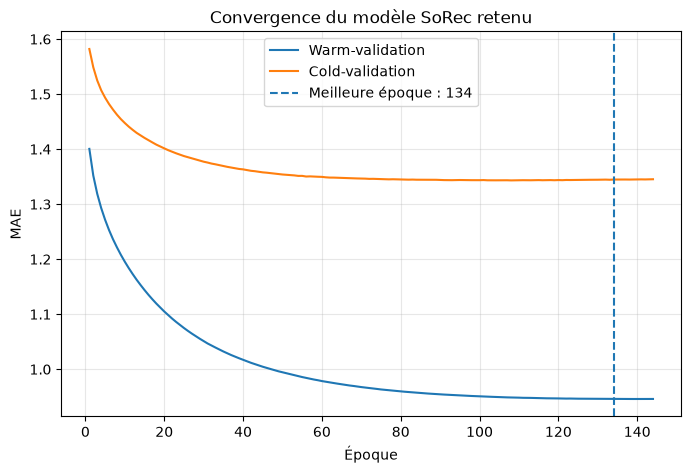

In [104]:
plt.figure(figsize=(8, 5))

plt.plot(
    sorec_history["epoch"],
    sorec_history["warm_MAE"],
    label="Warm-validation"
)

plt.plot(
    sorec_history["epoch"],
    sorec_history["cold_MAE"],
    label="Cold-validation"
)

plt.axvline(
    best_epoch_sorec,
    linestyle="--",
    label=f"Meilleure époque : {best_epoch_sorec}"
)

plt.xlabel("Époque")
plt.ylabel("MAE")
plt.title("Convergence du modèle SoRec retenu")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Cette implémentation de SoRec obtient des performances nettement inférieures à celles de la factorisation matricielle non sociale développée précédemment.

Elle n’est donc pas retenue pour l’évaluation finale. La suite du notebook conserve le principe central de SoRec — l’apprentissage conjoint d’une représentation utilisateur à partir des évaluations et du réseau de confiance — mais l’intègre directement à la factorisation matricielle utilisée dans la section 6 afin de maintenir un cadre de comparaison homogène entre les modèles social et non social.

## 8. Extension de la factorisation matricielle avec information sociale

### 8.1 Formulation

L’implémentation précédente de SoRec diffère de la factorisation matricielle non sociale à la fois par l’utilisation du réseau de confiance et par la formulation de la prédiction des notes.

Afin d’isoler plus directement l’apport de l’information sociale, une extension de la factorisation matricielle développée en section 6 est proposée.

La prédiction des notes conserve la formulation :

$$
\hat r_{ui}
=
\mu+b_u+b_i+U_u^\top V_i
$$

où $\mu$ représente la moyenne globale, $b_u$ et $b_i$ les biais utilisateur et item, et $U_u^\top V_i$ l'interaction latente.

Le vecteur utilisateur $U_u$ est cependant également utilisé pour modéliser les relations sociales :

$$
\hat c_{uk}=g(U_u^\top Z_k)
$$

où $Z_k$ représente l'utilisateur cible dans le réseau social et $g$ est la fonction logistique.

Ainsi, la représentation latente utilisateur est apprise conjointement à partir des évaluations et des relations de confiance.

La fonction d'apprentissage combine une erreur sur les évaluations et une erreur sur les relations sociales :

$$
L =
\frac12
\sum_{(u,i)\in T}
(r_{ui}-\hat r_{ui})^2
+
\frac{\lambda_C}{2}
\sum_{(u,k)\in C}
(c^*_{uk}-g(U_u^\top Z_k))^2
+
\text{régularisation}.
$$

Le paramètre $\lambda_C$ contrôle l'influence du réseau social.

### 8.2 Initialisation

In [82]:
def initialize_social_mf(
    n_users,
    n_items,
    n_factors,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    user_factors = rng.normal(
        0,
        0.01,
        size=(n_users, n_factors)
    ).astype(np.float32)

    item_factors = rng.normal(
        0,
        0.01,
        size=(n_items, n_factors)
    ).astype(np.float32)

    social_factors = rng.normal(
        0,
        0.01,
        size=(n_users, n_factors)
    ).astype(np.float32)

    user_bias = np.zeros(
        n_users,
        dtype=np.float32
    )

    item_bias = np.zeros(
        n_items,
        dtype=np.float32
    )

    return (
        user_factors,
        item_factors,
        social_factors,
        user_bias,
        item_bias
    )

In [83]:
def predict_social_mf(
    df,
    global_mean,
    user_factors,
    item_factors,
    user_bias,
    item_bias
):
    users = df["user_idx"].to_numpy(
        dtype=np.int32
    )

    items = df["item_idx"].to_numpy(
        dtype=np.int32
    )

    latent = np.sum(
        user_factors[users]
        * item_factors[items],
        axis=1
    )

    predictions = (
        global_mean
        + user_bias[users]
        + item_bias[items]
        + latent
    )

    return np.clip(
        predictions,
        1,
        5
    )

### 8.3 Entraînement conjoint
L’apprentissage alterne les mises à jour issues des évaluations et celles issues des relations de confiance. Le vecteur utilisateur $U_u$ intervient dans les deux composantes.

In [132]:
def fit_social_mf(
    user_idx,
    item_idx,
    ratings,
    social_source_idx,
    social_target_idx,
    social_weight,
    n_users,
    n_items,
    global_mean,
    val_df,
    val_ratings,
    cold_val_df,
    cold_val_ratings,
    n_factors=5,
    learning_rate=0.01,
    lambda_c=10.0,
    reg=0.05,
    max_epochs=100,
    patience=10,
    min_delta=1e-4,
    random_state=42,
    verbose=True,
    selection_metric="warm"
):

    (
        user_factors,
        item_factors,
        social_factors,
        user_bias,
        item_bias
    ) = initialize_social_mf(
        n_users,
        n_items,
        n_factors,
        random_state
    )

    rng = np.random.default_rng(random_state)

    n_ratings = len(ratings)
    n_social = len(social_weight)

    user_counts = np.bincount(
        user_idx,
        minlength=n_users
    )

    history = []

    best_selection_mae = np.inf
    best_epoch = 0
    best_params = None
    no_improvement = 0

    for epoch in range(max_epochs):

        # 1. Mise à jour des ratings

        rating_order = rng.permutation(
            n_ratings
        )

        for idx in rating_order:

            u = user_idx[idx]
            i = item_idx[idx]
            r = ratings[idx]

            U_old = user_factors[u].copy()
            V_old = item_factors[i].copy()

            pred = (
                global_mean
                + user_bias[u]
                + item_bias[i]
                + np.dot(
                    U_old,
                    V_old
                )
            )

            error = r - pred

            user_bias[u] += learning_rate * (
                error
                - reg * user_bias[u]
            )

            item_bias[i] += learning_rate * (
                error
                - reg * item_bias[i]
            )

            user_factors[u] += learning_rate * (
                error * V_old
                - reg * U_old
            )

            item_factors[i] += learning_rate * (
                error * U_old
                - reg * V_old
            )

        # 2. Mise à jour sociale

        social_order = rng.permutation(
            n_social
        )

        for idx in social_order:

            u = social_source_idx[idx]
            k = social_target_idx[idx]
            c = social_weight[idx]

            U_old = user_factors[u].copy()
            Z_old = social_factors[k].copy()

            score = np.dot(
                U_old,
                Z_old
            )

            pred_social = sigmoid(
                score
            )

            derivative = (
                pred_social
                * (1.0 - pred_social)
            )

            error_social = (
                c - pred_social
            )

            user_factors[u] += learning_rate * (
                lambda_c
                * error_social
                * derivative
                * Z_old
                - reg * U_old
            )

            social_factors[k] += learning_rate * (
                lambda_c
                * error_social
                * derivative
                * U_old
                - reg * Z_old
            )

        # Les utilisateurs sans rating conservent leurs
        # facteurs utilisateurs appris par le réseau social.
        # Leur biais utilisateur reste nul.

        user_bias[
            user_counts == 0
        ] = 0

        # 3. Validation
        

        pred_warm = predict_social_mf(
            val_df,
            global_mean,
            user_factors,
            item_factors,
            user_bias,
            item_bias
        )

        warm_mae = mae(
            val_ratings,
            pred_warm
        )

        pred_cold = predict_social_mf(
            cold_val_df,
            global_mean,
            user_factors,
            item_factors,
            user_bias,
            item_bias
        )

        cold_mae = mae(
            cold_val_ratings,
            pred_cold
        )

        history.append({
            "epoch": epoch + 1,
            "warm_MAE": warm_mae,
            "cold_MAE": cold_mae
        })

        if verbose:
            print(
                f"Epoch {epoch + 1:3d} "
                f"- warm MAE : {warm_mae:.4f} "
                f"- cold MAE : {cold_mae:.4f}"
            )

        # 4. Critère de sélection

        if selection_metric == "warm":
            selection_mae = warm_mae

        elif selection_metric == "cold":
            selection_mae = cold_mae

        else:
            raise ValueError(
                "selection_metric doit être "
                "'warm' ou 'cold'."
            )

        # 5. Early stopping

        if (
            best_selection_mae
            - selection_mae
            > min_delta
        ):

            best_selection_mae = selection_mae
            best_epoch = epoch + 1
            no_improvement = 0

            best_params = (
                user_factors.copy(),
                item_factors.copy(),
                social_factors.copy(),
                user_bias.copy(),
                item_bias.copy()
            )

        else:
            no_improvement += 1

        if no_improvement >= patience:

            if verbose:
                print(
                    f"Early stopping à "
                    f"l'époque {epoch + 1} "
                    f"(meilleure époque : "
                    f"{best_epoch})"
                )

            break

    # 6. Restauration du meilleur modèle
    
    if best_params is not None:

        (
            user_factors,
            item_factors,
            social_factors,
            user_bias,
            item_bias
        ) = best_params

    return (
        user_factors,
        item_factors,
        social_factors,
        user_bias,
        item_bias,
        pd.DataFrame(history),
        best_epoch,
        best_selection_mae
    )

### 8.4 Vérification initiale du modèle

In [133]:
(
    U_social_test,
    V_social_test,
    Z_social_test,
    user_bias_social_test,
    item_bias_social_test,
    social_mf_history_test,
    best_epoch_social_test,
    best_mae_social_test
) = fit_social_mf(
    train_users_idx,
    train_items_idx,
    train_ratings,
    social_source_idx,
    social_target_idx,
    social_weight,
    n_users,
    n_items,
    global_mean,
    val_df=warm_val_encoded,
    val_ratings=y_warm_val,
    cold_val_df=cold_val_encoded,
    cold_val_ratings=y_cold_val,
    n_factors=5,
    learning_rate=0.01,
    lambda_c=5,
    reg=0.05,
    max_epochs=20,
    patience=5,
    min_delta=1e-4,
    random_state=RANDOM_STATE,
    verbose=True
)

Epoch   1 - warm MAE : 0.8846 - cold MAE : 1.1135
Epoch   2 - warm MAE : 0.8649 - cold MAE : 1.0940
Epoch   3 - warm MAE : 0.8531 - cold MAE : 1.0827
Epoch   4 - warm MAE : 0.8455 - cold MAE : 1.0755
Epoch   5 - warm MAE : 0.8400 - cold MAE : 1.0690
Epoch   6 - warm MAE : 0.8350 - cold MAE : 1.0649
Epoch   7 - warm MAE : 0.8316 - cold MAE : 1.0612
Epoch   8 - warm MAE : 0.8285 - cold MAE : 1.0566
Epoch   9 - warm MAE : 0.8261 - cold MAE : 1.0541
Epoch  10 - warm MAE : 0.8241 - cold MAE : 1.0520
Epoch  11 - warm MAE : 0.8222 - cold MAE : 1.0503
Epoch  12 - warm MAE : 0.8209 - cold MAE : 1.0484
Epoch  13 - warm MAE : 0.8195 - cold MAE : 1.0472
Epoch  14 - warm MAE : 0.8180 - cold MAE : 1.0457
Epoch  15 - warm MAE : 0.8172 - cold MAE : 1.0448
Epoch  16 - warm MAE : 0.8161 - cold MAE : 1.0432
Epoch  17 - warm MAE : 0.8153 - cold MAE : 1.0423
Epoch  18 - warm MAE : 0.8144 - cold MAE : 1.0412
Epoch  19 - warm MAE : 0.8135 - cold MAE : 1.0397
Epoch  20 - warm MAE : 0.8129 - cold MAE : 1.0396


In [134]:
best_row_social = social_mf_history_test.loc[
    social_mf_history_test[
        "epoch"
    ] == best_epoch_social_test
].iloc[0]

print(
    f"Meilleure époque : "
    f"{best_epoch_social_test}"
)

print(
    f"MAE warm-validation : "
    f"{best_row_social['warm_MAE']:.4f}"
)

print(
    f"MAE cold-validation : "
    f"{best_row_social['cold_MAE']:.4f}"
)

Meilleure époque : 20
MAE warm-validation : 0.8129
MAE cold-validation : 1.0396


### 8.5 Influence de $\lambda_C$

Le paramètre $\lambda_C$ contrôle l’importance accordée à la composante sociale.

Plusieurs valeurs sont comparées en conservant les autres hyperparamètres constants. La sélection est effectuée à partir de la MAE sur la validation warm-start.

La valeur $\lambda_C=0$ correspond à une désactivation de la composante sociale et sert de référence.

In [135]:
lambda_values_social_mf = [
    0,
    1,
    5,
    10,
    20
]

lambda_results_social_mf = []

for lambda_c in lambda_values_social_mf:

    (
        U_tmp,
        V_tmp,
        Z_tmp,
        user_bias_tmp,
        item_bias_tmp,
        history_tmp,
        best_epoch_tmp,
        best_mae_tmp
    ) = fit_social_mf(
        train_users_idx,
        train_items_idx,
        train_ratings,
        social_source_idx,
        social_target_idx,
        social_weight,
        n_users,
        n_items,
        global_mean,
        val_df=warm_val_encoded,
        val_ratings=y_warm_val,
        cold_val_df=cold_val_encoded,
        cold_val_ratings=y_cold_val,
        n_factors=5,
        learning_rate=0.01,
        lambda_c=lambda_c,
        reg=0.05,
        max_epochs=60,
        patience=10,
        min_delta=1e-4,
        random_state=RANDOM_STATE,
        verbose=False
    )

    best_idx = (
        history_tmp["warm_MAE"]
        .idxmin()
    )

    lambda_results_social_mf.append({
        "lambda_c": lambda_c,
        "best_epoch": int(
            history_tmp.loc[
                best_idx,
                "epoch"
            ]
        ),
        "MAE_warm": history_tmp.loc[
            best_idx,
            "warm_MAE"
        ],
        "MAE_cold": history_tmp.loc[
            best_idx,
            "cold_MAE"
        ]
    })

lambda_results_social_mf = (
    pd.DataFrame(lambda_results_social_mf)
    .sort_values("MAE_warm")
    .reset_index(drop=True)
)

lambda_results_social_mf

,lambda_c,best_epoch,MAE_warm,MAE_cold
0,5,35,0.808442,1.033404
1,10,32,0.808783,1.033508
2,20,25,0.809072,1.037159
3,1,35,0.809757,1.033905
4,0,35,0.809763,1.033908


In [136]:
best_lambda_social_mf = float(
    lambda_results_social_mf.loc[
        0,
        "lambda_c"
    ]
)

print(
    f"lambda_c retenu pour la MF sociale : "
    f"{best_lambda_social_mf:g}"
)

lambda_c retenu pour la MF sociale : 5


La valeur $\lambda_C=5$ minimise la MAE sur la validation warm-start et est retenue pour la suite.

### 8.6 Influence de la dimension latente

Après avoir retenu $\lambda_C=5$, les dimensions latentes $k=5$, $k=10$ et $k=20$ sont comparées.

La sélection est effectuée à partir de la MAE sur la validation warm-start.

In [137]:
factor_values_social_mf = [
    5,
    10,
    20
]

factor_results_social_mf = []

for n_factors in factor_values_social_mf:

    (
        U_tmp,
        V_tmp,
        Z_tmp,
        user_bias_tmp,
        item_bias_tmp,
        history_tmp,
        best_epoch_tmp,
        best_mae_tmp
    ) = fit_social_mf(
        train_users_idx,
        train_items_idx,
        train_ratings,
        social_source_idx,
        social_target_idx,
        social_weight,
        n_users,
        n_items,
        global_mean,
        val_df=warm_val_encoded,
        val_ratings=y_warm_val,
        cold_val_df=cold_val_encoded,
        cold_val_ratings=y_cold_val,
        n_factors=n_factors,
        learning_rate=0.01,
        lambda_c=5,
        reg=0.05,
        max_epochs=60,
        patience=10,
        min_delta=1e-4,
        random_state=RANDOM_STATE,
        verbose=False
    )

    best_idx = (
        history_tmp["warm_MAE"]
        .idxmin()
    )

    factor_results_social_mf.append({
        "n_factors": n_factors,
        "best_epoch": int(
            history_tmp.loc[
                best_idx,
                "epoch"
            ]
        ),
        "MAE_warm": history_tmp.loc[
            best_idx,
            "warm_MAE"
        ],
        "MAE_cold": history_tmp.loc[
            best_idx,
            "cold_MAE"
        ]
    })

factor_results_social_mf = (
    pd.DataFrame(factor_results_social_mf)
    .sort_values("MAE_warm")
    .reset_index(drop=True)
)

factor_results_social_mf

,n_factors,best_epoch,MAE_warm,MAE_cold
0,5,35,0.808442,1.033404
1,20,32,0.808832,1.033733
2,10,32,0.808895,1.032875


In [138]:
best_n_factors_social_mf = int(
    factor_results_social_mf.loc[
        0,
        "n_factors"
    ]
)

print(
    f"Dimension MF sociale retenue : "
    f"{best_n_factors_social_mf}"
)

Dimension MF sociale retenue : 5


La dimension $k=5$ minimise la MAE sur la validation warm-start et est retenue pour la suite.

### 8.7 Influence du taux d'apprentissage

Après avoir retenu $\lambda_C=5$ et $k=5$, plusieurs taux d’apprentissage sont comparés en conservant les autres hyperparamètres constants.

La sélection est effectuée à partir de la MAE sur la validation warm-start.

In [139]:
learning_rate_values_social_mf = [
    0.005,
    0.01,
    0.02
]

lr_results_social_mf = []

for learning_rate in learning_rate_values_social_mf:

    (
        U_tmp,
        V_tmp,
        Z_tmp,
        user_bias_tmp,
        item_bias_tmp,
        history_tmp,
        best_epoch_tmp,
        best_mae_tmp
    ) = fit_social_mf(
        train_users_idx,
        train_items_idx,
        train_ratings,
        social_source_idx,
        social_target_idx,
        social_weight,
        n_users,
        n_items,
        global_mean,
        val_df=warm_val_encoded,
        val_ratings=y_warm_val,
        cold_val_df=cold_val_encoded,
        cold_val_ratings=y_cold_val,
        n_factors=best_n_factors_social_mf,
        learning_rate=learning_rate,
        lambda_c=best_lambda_social_mf,
        reg=0.05,
        max_epochs=60,
        patience=10,
        min_delta=1e-4,
        random_state=RANDOM_STATE,
        verbose=False
    )

    best_idx = (
        history_tmp["warm_MAE"]
        .idxmin()
    )

    lr_results_social_mf.append({
        "learning_rate": learning_rate,
        "best_epoch": int(
            history_tmp.loc[
                best_idx,
                "epoch"
            ]
        ),
        "MAE_warm": history_tmp.loc[
            best_idx,
            "warm_MAE"
        ],
        "MAE_cold": history_tmp.loc[
            best_idx,
            "cold_MAE"
        ]
    })

lr_results_social_mf = (
    pd.DataFrame(lr_results_social_mf)
    .sort_values("MAE_warm")
    .reset_index(drop=True)
)

lr_results_social_mf

,learning_rate,best_epoch,MAE_warm,MAE_cold
0,0.010,35,0.808442,1.033404
1,0.005,59,0.808665,1.034915
2,0.020,18,0.809070,1.031994


In [140]:
best_lr_social_mf = float(
    lr_results_social_mf.loc[
        0,
        "learning_rate"
    ]
)

print(
    f"Learning rate MF sociale retenu : "
    f"{best_lr_social_mf}"
)

Learning rate MF sociale retenu : 0.01


Le taux d’apprentissage $\eta=0{,}01$ minimise la MAE sur la validation warm-start et est retenu.

### 8.8 Influence de la régularisation

Après avoir sélectionné $\lambda_C$, la dimension latente et le taux d’apprentissage, plusieurs valeurs de régularisation sont comparées.

La sélection est effectuée à partir de la MAE sur la validation warm-start.

In [162]:
reg_values_social_mf = [
    0.01,
    0.05,
    0.10
]

reg_results_social_mf = []

for reg in reg_values_social_mf:

    (
        U_tmp,
        V_tmp,
        Z_tmp,
        user_bias_tmp,
        item_bias_tmp,
        history_tmp,
        best_epoch_tmp,
        best_mae_tmp
    ) = fit_social_mf(
        train_users_idx,
        train_items_idx,
        train_ratings,
        social_source_idx,
        social_target_idx,
        social_weight,
        n_users,
        n_items,
        global_mean,
        val_df=warm_val_encoded,
        val_ratings=y_warm_val,
        cold_val_df=cold_val_encoded,
        cold_val_ratings=y_cold_val,
        n_factors=best_n_factors_social_mf,
        learning_rate=best_lr_social_mf,
        lambda_c=best_lambda_social_mf,
        reg=reg,
        max_epochs=100,
        patience=10,
        min_delta=1e-4,
        random_state=RANDOM_STATE,
        verbose=False
    )

    best_idx = (
        history_tmp["warm_MAE"]
        .idxmin()
    )

    reg_results_social_mf.append({
        "reg": reg,
        "best_epoch": int(
            history_tmp.loc[
                best_idx,
                "epoch"
            ]
        ),
        "MAE_warm": history_tmp.loc[
            best_idx,
            "warm_MAE"
        ],
        "MAE_cold": history_tmp.loc[
            best_idx,
            "cold_MAE"
        ]
    })

reg_results_social_mf = (
    pd.DataFrame(reg_results_social_mf)
    .sort_values("MAE_warm")
    .reset_index(drop=True)
)

reg_results_social_mf

,reg,best_epoch,MAE_warm,MAE_cold
0,0.05,35,0.808442,1.033404
1,0.01,25,0.808664,1.033758
2,0.10,45,0.811087,1.033766


In [163]:
best_reg_social_mf = float(
    reg_results_social_mf.loc[
        0,
        "reg"
    ]
)

print(
    f"Régularisation MF sociale retenue : "
    f"{best_reg_social_mf}"
)

Régularisation MF sociale retenue : 0.05


La régularisation $\lambda=0{,}05$ minimise la MAE sur la validation warm-start et est retenue.

### 8.9 Sélection d'une configuration orientée cold-start
Une seconde recherche est réalisée en utilisant cette fois la MAE sur la validation cold-start comme critère de sélection.

La composante sociale permet aux utilisateurs cold-start d’apprendre une représentation latente à partir de leurs relations de confiance, malgré l’absence d’évaluations dans le jeu d’apprentissage.

Le jeu de test n’intervient pas dans cette sélection.

#### 8.9.1 Recherche de $\lambda_c$ orientée cold-start

In [143]:
lambda_values_cold = [
    0,
    1,
    5,
    10,
    20
]

lambda_results_cold = []

for lambda_c in lambda_values_cold:

    (
        U_tmp,
        V_tmp,
        Z_tmp,
        user_bias_tmp,
        item_bias_tmp,
        history_tmp,
        best_epoch_tmp,
        best_mae_tmp
    ) = fit_social_mf(
        train_users_idx,
        train_items_idx,
        train_ratings,
        social_source_idx,
        social_target_idx,
        social_weight,
        n_users,
        n_items,
        global_mean,
        val_df=warm_val_encoded,
        val_ratings=y_warm_val,
        cold_val_df=cold_val_encoded,
        cold_val_ratings=y_cold_val,
        n_factors=5,
        learning_rate=0.005,
        lambda_c=lambda_c,
        reg=0.05,
        max_epochs=100,
        patience=10,
        min_delta=1e-4,
        random_state=RANDOM_STATE,
        verbose=False,
        selection_metric="cold"
    )

    best_idx = (
        history_tmp["cold_MAE"]
        .idxmin()
    )

    lambda_results_cold.append({
        "lambda_c": lambda_c,
        "best_epoch": int(
            history_tmp.loc[
                best_idx,
                "epoch"
            ]
        ),
        "MAE_warm": history_tmp.loc[
            best_idx,
            "warm_MAE"
        ],
        "MAE_cold": history_tmp.loc[
            best_idx,
            "cold_MAE"
        ]
    })

lambda_results_cold = (
    pd.DataFrame(lambda_results_cold)
    .sort_values("MAE_cold")
    .reset_index(drop=True)
)

lambda_results_cold

,lambda_c,best_epoch,MAE_warm,MAE_cold
0,5,100,0.814417,1.029707
1,1,100,0.815410,1.030975
2,0,100,0.815425,1.030996
3,10,82,0.811554,1.032303
4,20,76,0.812761,1.034053


In [144]:
best_lambda_cold = float(
    lambda_results_cold.loc[
        0,
        "lambda_c"
    ]
)

print(
    f"lambda_c retenu pour le cold-start : "
    f"{best_lambda_cold:g}"
)

lambda_c retenu pour le cold-start : 5


In [145]:
(
    U_cold_tmp,
    V_cold_tmp,
    Z_cold_tmp,
    user_bias_cold_tmp,
    item_bias_cold_tmp,
    history_cold_lambda5,
    best_epoch_cold_lambda5,
    best_mae_cold_lambda5
) = fit_social_mf(
    train_users_idx,
    train_items_idx,
    train_ratings,
    social_source_idx,
    social_target_idx,
    social_weight,
    n_users,
    n_items,
    global_mean,
    val_df=warm_val_encoded,
    val_ratings=y_warm_val,
    cold_val_df=cold_val_encoded,
    cold_val_ratings=y_cold_val,
    n_factors=5,
    learning_rate=0.005,
    lambda_c=5,
    reg=0.05,
    max_epochs=200,
    patience=10,
    min_delta=1e-4,
    random_state=RANDOM_STATE,
    verbose=False,
    selection_metric="cold"
)

best_idx = history_cold_lambda5["cold_MAE"].idxmin()

print(
    "Meilleure époque :",
    int(
        history_cold_lambda5.loc[
            best_idx,
            "epoch"
        ]
    )
)

print(
    "MAE warm :",
    round(
        history_cold_lambda5.loc[
            best_idx,
            "warm_MAE"
        ],
        6
    )
)

print(
    "MAE cold :",
    round(
        history_cold_lambda5.loc[
            best_idx,
            "cold_MAE"
        ],
        6
    )
)

Meilleure époque : 116
MAE warm : 0.819658
MAE cold : 1.029231


Pour $\lambda_C=5$, la meilleure MAE cold-start du premier entraînement est atteinte à la dernière époque autorisée. Un entraînement plus long est donc réalisé afin de vérifier la convergence.

La meilleure MAE cold-start est finalement obtenue à l’époque 116.

La valeur $\lambda_C=5$ est retenue pour la suite.

#### 8.9.2 Influence de la dimension latente

Après avoir retenu $\lambda_C=5$, les dimensions $k=5$, $k=10$ et $k=20$ sont comparées.

La sélection et l’early stopping sont effectués à partir de la MAE sur la validation cold-start.

In [146]:
factor_values_cold = [
    5,
    10,
    20
]

factor_results_cold = []

for n_factors in factor_values_cold:

    (
        U_tmp,
        V_tmp,
        Z_tmp,
        user_bias_tmp,
        item_bias_tmp,
        history_tmp,
        best_epoch_tmp,
        best_mae_tmp
    ) = fit_social_mf(
        train_users_idx,
        train_items_idx,
        train_ratings,
        social_source_idx,
        social_target_idx,
        social_weight,
        n_users,
        n_items,
        global_mean,
        val_df=warm_val_encoded,
        val_ratings=y_warm_val,
        cold_val_df=cold_val_encoded,
        cold_val_ratings=y_cold_val,
        n_factors=n_factors,
        learning_rate=0.005,
        lambda_c=5,
        reg=0.05,
        max_epochs=200,
        patience=10,
        min_delta=1e-4,
        random_state=RANDOM_STATE,
        verbose=False,
        selection_metric="cold"
    )

    best_idx = (
        history_tmp["cold_MAE"]
        .idxmin()
    )

    factor_results_cold.append({
        "n_factors": n_factors,
        "best_epoch": int(
            history_tmp.loc[
                best_idx,
                "epoch"
            ]
        ),
        "MAE_warm": history_tmp.loc[
            best_idx,
            "warm_MAE"
        ],
        "MAE_cold": history_tmp.loc[
            best_idx,
            "cold_MAE"
        ]
    })

factor_results_cold = (
    pd.DataFrame(factor_results_cold)
    .sort_values("MAE_cold")
    .reset_index(drop=True)
)

factor_results_cold

,n_factors,best_epoch,MAE_warm,MAE_cold
0,10,116,0.823442,1.028502
1,5,116,0.819658,1.029231
2,20,116,0.822111,1.030723


In [147]:
best_n_factors_cold = int(
    factor_results_cold.loc[
        0,
        "n_factors"
    ]
)
print(
    f"Dimension latente MF sociale cold-start retenue : "
    f"{best_n_factors_cold}"
)

Dimension latente MF sociale cold-start retenue : 10


La dimension $k=10$ minimise la MAE sur la validation cold-start et est retenue pour la suite.

#### 8.9.3 Influence du taux d’apprentissage

Après avoir retenu $\lambda_C=5$ et $k=10$, plusieurs taux d’apprentissage sont comparés.

La sélection et l’early stopping sont effectués à partir de la MAE sur la validation cold-start.

In [148]:
learning_rate_values_cold = [
    0.005,
    0.01,
    0.02
]

lr_results_cold = []

for learning_rate in learning_rate_values_cold:

    (
        U_tmp,
        V_tmp,
        Z_tmp,
        user_bias_tmp,
        item_bias_tmp,
        history_tmp,
        best_epoch_tmp,
        best_mae_tmp
    ) = fit_social_mf(
        train_users_idx,
        train_items_idx,
        train_ratings,
        social_source_idx,
        social_target_idx,
        social_weight,
        n_users,
        n_items,
        global_mean,
        val_df=warm_val_encoded,
        val_ratings=y_warm_val,
        cold_val_df=cold_val_encoded,
        cold_val_ratings=y_cold_val,
        n_factors=best_n_factors_cold,
        learning_rate=learning_rate,
        lambda_c=best_lambda_cold,
        reg=0.05,
        max_epochs=200,
        patience=10,
        min_delta=1e-4,
        random_state=RANDOM_STATE,
        verbose=False,
        selection_metric="cold"
    )

    best_idx = (
        history_tmp["cold_MAE"]
        .idxmin()
    )

    lr_results_cold.append({
        "learning_rate": learning_rate,
        "best_epoch": int(
            history_tmp.loc[
                best_idx,
                "epoch"
            ]
        ),
        "MAE_warm": history_tmp.loc[
            best_idx,
            "warm_MAE"
        ],
        "MAE_cold": history_tmp.loc[
            best_idx,
            "cold_MAE"
        ]
    })

lr_results_cold = (
    pd.DataFrame(lr_results_cold)
    .sort_values("MAE_cold")
    .reset_index(drop=True)
)

lr_results_cold

,learning_rate,best_epoch,MAE_warm,MAE_cold
0,0.020,33,0.828543,1.028411
1,0.010,54,0.819890,1.028482
2,0.005,116,0.823442,1.028502


In [149]:
best_lr_cold = float(
    lr_results_cold.loc[
        0,
        "learning_rate"
    ]
)

print(
    f"Learning rate MF sociale cold-start retenu : "
    f"{best_lr_cold}"
)

Learning rate MF sociale cold-start retenu : 0.02


Le taux d’apprentissage $\eta=0{,}02$ minimise la MAE sur la validation cold-start et est retenu.

Il atteint également son meilleur résultat en moins d’époques que les valeurs plus faibles testées.

#### 8.9.4 Influence de la régularisation

Après avoir sélectionné $\lambda_C$, la dimension latente et le taux d’apprentissage, plusieurs valeurs de régularisation sont comparées.

La sélection et l’early stopping sont effectués à partir de la MAE sur la validation cold-start.

In [150]:
reg_values_cold = [
    0.01,
    0.05,
    0.10,
    0.20
]

reg_results_cold = []

for reg in reg_values_cold:

    (
        U_tmp,
        V_tmp,
        Z_tmp,
        user_bias_tmp,
        item_bias_tmp,
        history_tmp,
        best_epoch_tmp,
        best_mae_tmp
    ) = fit_social_mf(
        train_users_idx,
        train_items_idx,
        train_ratings,
        social_source_idx,
        social_target_idx,
        social_weight,
        n_users,
        n_items,
        global_mean,
        val_df=warm_val_encoded,
        val_ratings=y_warm_val,
        cold_val_df=cold_val_encoded,
        cold_val_ratings=y_cold_val,
        n_factors=best_n_factors_cold,
        learning_rate=best_lr_cold,
        lambda_c=best_lambda_cold,
        reg=reg,
        max_epochs=100,
        patience=10,
        min_delta=1e-4,
        random_state=RANDOM_STATE,
        verbose=False,
        selection_metric="cold"
    )

    best_idx = (
        history_tmp["cold_MAE"]
        .idxmin()
    )

    reg_results_cold.append({
        "reg": reg,
        "best_epoch": int(
            history_tmp.loc[
                best_idx,
                "epoch"
            ]
        ),
        "MAE_warm": history_tmp.loc[
            best_idx,
            "warm_MAE"
        ],
        "MAE_cold": history_tmp.loc[
            best_idx,
            "cold_MAE"
        ]
    })

reg_results_cold = (
    pd.DataFrame(reg_results_cold)
    .sort_values("MAE_cold")
    .reset_index(drop=True)
)

reg_results_cold

,reg,best_epoch,MAE_warm,MAE_cold
0,0.01,24,0.836891,1.026884
1,0.05,33,0.828543,1.028411
2,0.10,33,0.815784,1.031250
3,0.20,42,0.819602,1.033930


In [151]:
best_reg_cold = float(
    reg_results_cold.loc[
        0,
        "reg"
    ]
)

print(
    f"Régularisation MF sociale cold-start retenue : "
    f"{best_reg_cold}"
)

Régularisation MF sociale cold-start retenue : 0.01


La régularisation $\lambda=0{,}01$ minimise la MAE sur la validation cold-start et est retenue.

**Configuration sociale retenue pour le cold-start :**

* $\lambda_C=5$
* $k=10$
* $\eta=0{,}02$
* $\lambda=0{,}01$

Elle obtient une MAE de 1,0269 sur la validation cold-start et de 0,8369 sur la validation warm-start.

## 9. Évaluation finale et comparaison des modèles

### 9.1 Protocole d'évaluation finale

Les hyperparamètres ont été sélectionnés uniquement à partir des jeux d’apprentissage et de validation.

Les jeux de test, qui n’ont pas été utilisés lors de cette sélection, sont maintenant utilisés pour l’évaluation finale.

La MAE est utilisée comme métrique commune à l’ensemble des modèles.

### 9.2 Modèles retenus pour l’évaluation finale

Les modèles et configurations suivants sont évalués :

* moyenne globale ;
* modèle avec biais ;
* MF sélectionnée sur la validation warm-start ;
* MF sélectionnée sur la validation cold-start ;
* MF sociale sélectionnée sur la validation warm-start ;
* MF sociale sélectionnée sur la validation cold-start.

L’implémentation exploratoire de SoRec présentée en section 7 n’est pas retenue pour cette évaluation finale.

### 9.3 Préparation des cibles test

In [58]:
y_warm_test = (
    warm_test_encoded["rating"]
    .to_numpy(dtype=np.float32)
)

y_cold_test = (
    cold_test_encoded["rating"]
    .to_numpy(dtype=np.float32)
)

print(
    f"Warm-test : {len(y_warm_test):,} évaluations"
)

print(
    f"Cold-test : {len(y_cold_test):,} évaluations"
)

Warm-test : 94,443 évaluations
Cold-test : 2,000 évaluations


### 9.4 Évaluation finale de la MF non sociale

In [71]:
# MF sélectionnée sur warm-validation
pred_mf_warm_on_warm_test = predict_mf(
    warm_test_encoded,
    global_mean,
    user_factors_mf,
    item_factors_mf,
    user_bias_mf,
    item_bias_mf
)

pred_mf_warm_on_cold_test = predict_mf(
    cold_test_encoded,
    global_mean,
    user_factors_mf,
    item_factors_mf,
    user_bias_mf,
    item_bias_mf
)

# MF sélectionnée sur cold-validation
pred_mf_cold_on_warm_test = predict_mf(
    warm_test_encoded,
    global_mean,
    user_factors_mf_cold,
    item_factors_mf_cold,
    user_bias_mf_cold,
    item_bias_mf_cold
)

pred_mf_cold_on_cold_test = predict_mf(
    cold_test_encoded,
    global_mean,
    user_factors_mf_cold,
    item_factors_mf_cold,
    user_bias_mf_cold,
    item_bias_mf_cold
)

### 9.5 MF sociale sélectionnée sur la validation warm-start

In [153]:
def fit_social_mf_final(
    user_idx,
    item_idx,
    ratings,
    social_source_idx,
    social_target_idx,
    social_weight,
    n_users,
    n_items,
    global_mean,
    n_factors,
    learning_rate,
    lambda_c,
    reg,
    n_epochs,
    random_state=42
):

    (
        user_factors,
        item_factors,
        social_factors,
        user_bias,
        item_bias
    ) = initialize_social_mf(
        n_users,
        n_items,
        n_factors,
        random_state
    )

    rng = np.random.default_rng(
        random_state
    )

    n_ratings = len(ratings)
    n_social = len(social_weight)

    user_counts = np.bincount(
        user_idx,
        minlength=n_users
    )

    for epoch in range(n_epochs):

        # 1. Mise à jour des ratings

        rating_order = rng.permutation(
            n_ratings
        )

        for idx in rating_order:

            u = user_idx[idx]
            i = item_idx[idx]
            r = ratings[idx]

            U_old = user_factors[u].copy()
            V_old = item_factors[i].copy()

            pred = (
                global_mean
                + user_bias[u]
                + item_bias[i]
                + np.dot(
                    U_old,
                    V_old
                )
            )

            error = r - pred

            user_bias[u] += learning_rate * (
                error
                - reg * user_bias[u]
            )

            item_bias[i] += learning_rate * (
                error
                - reg * item_bias[i]
            )

            user_factors[u] += learning_rate * (
                error * V_old
                - reg * U_old
            )

            item_factors[i] += learning_rate * (
                error * U_old
                - reg * V_old
            )

        # 2. Mise à jour sociale

        social_order = rng.permutation(
            n_social
        )

        for idx in social_order:

            u = social_source_idx[idx]
            k = social_target_idx[idx]
            c = social_weight[idx]

            U_old = user_factors[u].copy()
            Z_old = social_factors[k].copy()

            pred_social = sigmoid(
                np.dot(
                    U_old,
                    Z_old
                )
            )

            derivative = (
                pred_social
                * (1.0 - pred_social)
            )

            error_social = (
                c - pred_social
            )

            user_factors[u] += learning_rate * (
                lambda_c
                * error_social
                * derivative
                * Z_old
                - reg * U_old
            )

            social_factors[k] += learning_rate * (
                lambda_c
                * error_social
                * derivative
                * U_old
                - reg * Z_old
            )

        # Les utilisateurs sans rating gardent
        # leurs facteurs appris socialement.
        # Leur biais utilisateur reste nul.

        user_bias[
            user_counts == 0
        ] = 0

    return (
        user_factors,
        item_factors,
        social_factors,
        user_bias,
        item_bias
    )

In [179]:
(
    U_social_warm,
    V_social_warm,
    Z_social_warm,
    user_bias_social_warm,
    item_bias_social_warm
) = fit_social_mf_final(
    train_users_idx,
    train_items_idx,
    train_ratings,
    social_source_idx,
    social_target_idx,
    social_weight,
    n_users,
    n_items,
    global_mean,
    n_factors=best_n_factors_social_mf,
    learning_rate=best_lr_social_mf,
    lambda_c=best_lambda_social_mf,
    reg=best_reg_social_mf,
    n_epochs=35,
    random_state=RANDOM_STATE
)

In [180]:
pred_social_warm_test = predict_social_mf(
    warm_test_encoded,
    global_mean,
    U_social_warm,
    V_social_warm,
    user_bias_social_warm,
    item_bias_social_warm
)

pred_social_warm_cold_test = predict_social_mf(
    cold_test_encoded,
    global_mean,
    U_social_warm,
    V_social_warm,
    user_bias_social_warm,
    item_bias_social_warm
)

social_warm_test_results = pd.DataFrame({
    "scénario": [
        "Warm-start",
        "Cold-start"
    ],
    "MAE": [
        mae(
            y_warm_test,
            pred_social_warm_test
        ),
        mae(
            y_cold_test,
            pred_social_warm_cold_test
        )
    ]
})

social_warm_test_results.round(4)

,scénario,MAE
0,Warm-start,0.8107
1,Cold-start,1.0294


In [181]:
pred_social_warm_val_check = predict_social_mf(
    warm_val_encoded,
    global_mean,
    U_social_warm,
    V_social_warm,
    user_bias_social_warm,
    item_bias_social_warm
)

mae_social_warm_val_check = mae(
    y_warm_val,
    pred_social_warm_val_check
)

print(
    f"MAE warm-validation du modèle final : "
    f"{mae_social_warm_val_check:.6f}"
)

MAE warm-validation du modèle final : 0.808442


### 9.6 MF sociale sélectionnée sur la validation cold-start

In [175]:
(
    U_social_cold,
    V_social_cold,
    Z_social_cold,
    user_bias_social_cold,
    item_bias_social_cold
) = fit_social_mf_final(
    train_users_idx,
    train_items_idx,
    train_ratings,
    social_source_idx,
    social_target_idx,
    social_weight,
    n_users,
    n_items,
    global_mean,
    n_factors=best_n_factors_cold,
    learning_rate=best_lr_cold,
    lambda_c=best_lambda_cold,
    reg=best_reg_cold,
    n_epochs=24,
    random_state=RANDOM_STATE
)

In [176]:
pred_social_cold_warm_test = predict_social_mf(
    warm_test_encoded,
    global_mean,
    U_social_cold,
    V_social_cold,
    user_bias_social_cold,
    item_bias_social_cold
)

pred_social_cold_test = predict_social_mf(
    cold_test_encoded,
    global_mean,
    U_social_cold,
    V_social_cold,
    user_bias_social_cold,
    item_bias_social_cold
)

social_cold_test_results = pd.DataFrame({
    "scénario": [
        "Warm-start",
        "Cold-start"
    ],
    "MAE": [
        mae(
            y_warm_test,
            pred_social_cold_warm_test
        ),
        mae(
            y_cold_test,
            pred_social_cold_test
        )
    ]
})

social_cold_test_results.round(4)

,scénario,MAE
0,Warm-start,0.8361
1,Cold-start,1.0222


### 9.7 Baselines

#### 9.7.1 Moyenne globale

In [159]:
pred_mean_warm_test = np.full(
    len(y_warm_test),
    global_mean
)

pred_mean_cold_test = np.full(
    len(y_cold_test),
    global_mean
)

mae_mean_warm_test = mae(
    y_warm_test,
    pred_mean_warm_test
)

mae_mean_cold_test = mae(
    y_cold_test,
    pred_mean_cold_test
)

print(
    f"Moyenne globale — warm-test : "
    f"{mae_mean_warm_test:.4f}"
)

print(
    f"Moyenne globale — cold-test : "
    f"{mae_mean_cold_test:.4f}"
)

Moyenne globale — warm-test : 0.9542
Moyenne globale — cold-test : 1.1780


#### 9.7.2 Modèle avec biais

In [129]:
pred_bias_warm_test = predict_bias_model(
    warm_test_encoded,
    global_mean,
    user_bias,
    item_bias
)

pred_bias_cold_test = predict_bias_model(
    cold_test_encoded,
    global_mean,
    user_bias,
    item_bias
)

mae_bias_warm_test = mae(
    y_warm_test,
    pred_bias_warm_test
)

mae_bias_cold_test = mae(
    y_cold_test,
    pred_bias_cold_test
)

print(
    f"Biais utilisateur + item — warm-test : "
    f"{mae_bias_warm_test:.4f}"
)

print(
    f"Biais item — cold-test : "
    f"{mae_bias_cold_test:.4f}"
)

Biais utilisateur + item — warm-test : 0.8103
Biais item — cold-test : 1.0366


### 9.8 Tableau comparatif final

Le tableau suivant rassemble les performances finales obtenues sur les jeux de test. L'écart entre les MAE cold-start et warm-start est présenté à titre descriptif afin de faciliter la comparaison du comportement des modèles dans les deux scénarios. Il doit toutefois être interprété avec précaution, les populations et les quantités de données utilisées pour les évaluations warm-start et cold-start étant différentes.

In [182]:
final_results = pd.DataFrame({
    "modèle": [
        "Moyenne globale",
        "Biais",
        "MF",
        "MF + social (warm)",
        "MF + social (cold)"
    ],
    "MAE_warm_test": [
        mae_mean_warm_test,
        mae_bias_warm_test,
        mae(
            y_warm_test,
            pred_mf_warm_test
        ),
        mae(
            y_warm_test,
            pred_social_warm_test
        ),
        mae(
            y_warm_test,
            pred_social_cold_warm_test
        )
    ],
    "MAE_cold_test": [
        mae_mean_cold_test,
        mae_bias_cold_test,
        mae(
            y_cold_test,
            pred_mf_cold_test
        ),
        mae(
            y_cold_test,
            pred_social_warm_cold_test
        ),
        mae(
            y_cold_test,
            pred_social_cold_test
        )
    ]
})
final_results["Écart cold-warm"] = (
    final_results["MAE_cold_test"]
    - final_results["MAE_warm_test"]
)
final_results.round(4)

,modèle,MAE_warm_test,MAE_cold_test,Écart cold-warm
0,Moyenne globale,0.9542,1.1780,0.2238
1,Biais,0.8103,1.0366,0.2264
2,MF,0.8132,1.0350,0.2218
3,MF + social (warm),0.8107,1.0294,0.2187
4,MF + social (cold),0.8361,1.0222,0.1861


Remarque : le modèle MF correspond au MF sélectionné warm-start. Le modèle MF orienté cold-start a été fait a posteriori de ce tableau.

### Ajout a posteriori : MF non sociale orientée cold-start

In [72]:
mf_test_comparison = pd.DataFrame({
    "configuration": [
        "MF sélectionnée warm-start",
        "MF sélectionnée cold-start"
    ],
    "MAE warm-test": [
        mae(
            y_warm_test,
            pred_mf_warm_on_warm_test
        ),
        mae(
            y_warm_test,
            pred_mf_cold_on_warm_test
        )
    ],
    "MAE cold-test": [
        mae(
            y_cold_test,
            pred_mf_warm_on_cold_test
        ),
        mae(
            y_cold_test,
            pred_mf_cold_on_cold_test
        )
    ]
})
mf_test_comparison["Écart cold-warm"] = (
    mf_test_comparison["MAE cold-test"]
    - mf_test_comparison["MAE warm-test"]
)

mf_test_comparison.round(4)

,configuration,MAE warm-test,MAE cold-test,Écart cold-warm
0,MF sélectionnée warm-start,0.8132,1.0350,0.2218
1,MF sélectionnée cold-start,0.8623,1.0254,0.1631
